In [1]:
# Batch 0 / Cell 1 - Imports, project root, output paths
from __future__ import annotations

import importlib
import inspect
import json
import re
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd


NOTEBOOK_ID = "23_stable_diffusion_difference_maps"
NOTEBOOK_LABEL = "Stable Diffusion Difference Maps"


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def find_project_root(start_path: Path | None = None) -> Path:
    start_path = Path.cwd() if start_path is None else Path(start_path).resolve()

    markers = [
        Path("tools/build_project_inventory.py"),
        Path("src/restoration_eval"),
    ]

    for candidate in [start_path, *start_path.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate

    raise RuntimeError(
        "Could not locate project root. Expected tools/build_project_inventory.py "
        "and src/restoration_eval under the same project root."
    )


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
INVENTORY_SCRIPT_PATH = PROJECT_ROOT / "tools" / "build_project_inventory.py"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


OUTPUT_ROOT = PROJECT_ROOT / "outputs" / NOTEBOOK_ID

OUTPUT_DIRS = {
    "root": OUTPUT_ROOT,
    "inventory": OUTPUT_ROOT / "inventory",
    "tables": OUTPUT_ROOT / "tables",
    "metrics": OUTPUT_ROOT / "metrics",
    "analysis": OUTPUT_ROOT / "analysis",
    "maps": OUTPUT_ROOT / "maps",
    "figures": OUTPUT_ROOT / "figures",
    "reports": OUTPUT_ROOT / "reports",
    "manifests": OUTPUT_ROOT / "manifests",
    "validation": OUTPUT_ROOT / "validation",
}

for output_dir in OUTPUT_DIRS.values():
    output_dir.mkdir(parents=True, exist_ok=True)


GLOBAL_INVENTORY_DIR = PROJECT_ROOT / "outputs" / "inventory"
GLOBAL_INVENTORY_CSV_PATH = GLOBAL_INVENTORY_DIR / "project_file_inventory.csv"
GLOBAL_INVENTORY_MANIFEST_PATH = GLOBAL_INVENTORY_DIR / "project_file_inventory_manifest.json"

BATCH0_INVENTORY_SNAPSHOT_PATH = OUTPUT_DIRS["inventory"] / "batch0_project_inventory_snapshot.csv"
BATCH0_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch0_validation.csv"
STAGE_MANIFEST_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_maps_stage_manifest.json"


UPSTREAM_ARTIFACTS = {
    "notebook22_handoff_manifest": PROJECT_ROOT / "outputs/22_stable_diffusion_classical_metrics/manifests/stable_diffusion_classical_metrics_handoff_manifest.json",
    "notebook22_final_validation": PROJECT_ROOT / "outputs/22_stable_diffusion_classical_metrics/validation/stable_diffusion_classical_metrics_final_validation.csv",
    "candidate_input_cases": PROJECT_ROOT / "outputs/22_stable_diffusion_classical_metrics/tables/stable_diffusion_classical_metric_input_cases.csv",
    "classical_metrics": PROJECT_ROOT / "outputs/22_stable_diffusion_classical_metrics/metrics/stable_diffusion_classical_metrics.csv",
    "selected_cases": PROJECT_ROOT / "outputs/22_stable_diffusion_classical_metrics/analysis/stable_diffusion_classical_metric_selected_cases.csv",
}


def rel(path: str | Path) -> str:
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()


def validation_row(
    check_name: str,
    observed_value,
    expected_value,
    passed: bool,
    failure_message: str,
) -> dict:
    return {
        "check_name": check_name,
        "observed_value": observed_value,
        "expected_value": expected_value,
        "passed": bool(passed),
        "failure_message": "" if bool(passed) else failure_message,
        "validated_at_utc": utc_now_iso(),
    }


def bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False)

    normalized = series.astype(str).str.strip().str.lower()
    return normalized.isin(["true", "1", "yes", "y", "passed"])


def read_csv_columns(path: Path) -> list[str]:
    if not path.is_file():
        return []
    return list(pd.read_csv(path, nrows=0).columns)


print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook output root: {rel(OUTPUT_ROOT)}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: outputs/23_stable_diffusion_difference_maps


In [2]:
# Batch 0 / Cell 2 - Refresh project inventory
if not INVENTORY_SCRIPT_PATH.is_file():
    raise FileNotFoundError(f"Missing inventory script: {INVENTORY_SCRIPT_PATH}")

inventory_command = [
    sys.executable,
    str(INVENTORY_SCRIPT_PATH),
    "--root",
    str(PROJECT_ROOT),
    "--out-dir",
    str(GLOBAL_INVENTORY_DIR),
]

inventory_run = subprocess.run(
    inventory_command,
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=False,
)

print("Inventory command:")
print(" ".join(inventory_command))

print("\nSTDOUT:")
print(inventory_run.stdout)

if inventory_run.stderr.strip():
    print("\nSTDERR:")
    print(inventory_run.stderr)

if inventory_run.returncode != 0:
    raise RuntimeError(f"Inventory refresh failed with return code {inventory_run.returncode}.")

if not GLOBAL_INVENTORY_CSV_PATH.is_file():
    raise FileNotFoundError(f"Inventory CSV was not produced: {GLOBAL_INVENTORY_CSV_PATH}")

inventory_df = pd.read_csv(GLOBAL_INVENTORY_CSV_PATH)
inventory_df.to_csv(BATCH0_INVENTORY_SNAPSHOT_PATH, index=False)

print(f"Inventory rows: {len(inventory_df):,}")
print(f"Saved Batch 0 inventory snapshot: {rel(BATCH0_INVENTORY_SNAPSHOT_PATH)}")
display(inventory_df.head(10))

Inventory command:
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Scripts\python.exe D:\Masters\FH\Thesis\painting-restoration-eval\tools\build_project_inventory.py --root D:\Masters\FH\Thesis\painting-restoration-eval --out-dir D:\Masters\FH\Thesis\painting-restoration-eval\outputs\inventory

STDOUT:
Saved inventory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\inventory\project_file_inventory.csv
Saved summary:   D:\Masters\FH\Thesis\painting-restoration-eval\outputs\inventory\project_file_inventory_summary.csv
Files indexed:   4150

Inventory rows: 4,150
Saved Batch 0 inventory snapshot: outputs/23_stable_diffusion_difference_maps/inventory/batch0_project_inventory_snapshot.csv


,relative_path,file_name,parent_dir,extension,file_kind,size_bytes,last_modified_iso,depth,csv_row_count,csv_column_count,csv_columns,csv_error,image_width,image_height,image_mode,image_error,sha256_first_1mb
0,.gitattributes,.gitattributes,NaN,NaN,other,60,2026-07-06T17:52:52.879628+00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,439ad27a2f48aacaaf48efa19bc2f8b8fcb5b402d23454...
1,.gitignore,.gitignore,NaN,NaN,other,643,2026-07-06T17:53:38.894066+00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d4ef631ec54b12485b0f98e910cc14d435433c33f26489...
2,config/experiment_50_config.yaml,experiment_50_config.yaml,config,.yaml,other,7111,2026-07-23T12:34:35.693189+00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7af22deb75434907302e3e460b4c28a73f25533f3274e4...
3,config/pilot_config.yaml,pilot_config.yaml,config,.yaml,other,677,2026-06-29T14:26:59.322671+00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9c81e4ee3aec9dc1b86aa6bc28f5ba442b694810d83eed...
4,data/model_audit/model_candidates.csv,model_candidates.csv,data/model_audit,.csv,csv,5383,2026-07-03T09:14:19.349960+00:00,2,5.0,17.0,model_name | model_family | open_or_closed | d...,NaN,NaN,NaN,NaN,NaN,4ec7ee8d89e5a9d122ea5e9dd37efa6346a6f686263d66...
5,data/processed/clean/p001_clean.png,p001_clean.png,data/processed/clean,.png,clean_image,723881,2026-07-24T16:38:17.470158+00:00,3,NaN,NaN,NaN,NaN,768.0,768.0,RGB,NaN,b5852f0337c8342a1a70268f9e9f682534177581d23871...
6,data/processed/clean/p002_clean.png,p002_clean.png,data/processed/clean,.png,clean_image,339472,2026-07-24T16:38:18.292719+00:00,3,NaN,NaN,NaN,NaN,768.0,768.0,RGB,NaN,3f173a947e4c2be2ebdc267f0c852f490981bc81da6c4e...
7,data/processed/clean/p003_clean.png,p003_clean.png,data/processed/clean,.png,clean_image,648764,2026-07-24T16:38:19.476394+00:00,3,NaN,NaN,NaN,NaN,768.0,768.0,RGB,NaN,1e2ef6b59b4383d7d44ce2f9bb016c126633d2c3e4f39b...
8,data/processed/clean/p004_clean.png,p004_clean.png,data/processed/clean,.png,clean_image,709746,2026-07-24T16:38:20.522805+00:00,3,NaN,NaN,NaN,NaN,768.0,768.0,RGB,NaN,ae8cfa01d84bd2e8c2f41cfdfe1cb25b6f2abf34301351...
9,data/processed/clean/p005_clean.png,p005_clean.png,data/processed/clean,.png,clean_image,745221,2026-07-24T16:38:21.522086+00:00,3,NaN,NaN,NaN,NaN,768.0,768.0,RGB,NaN,da4c53324f40a8a662edb554ee6215db2a53bcb94fcdb7...


In [3]:
# Batch 0 / Cell 3 - Inventory helpers and upstream contract scan
def inventory_contains_path(path: Path) -> bool:
    relative = rel(path)
    if "relative_path" not in inventory_df.columns:
        return False
    return bool(inventory_df["relative_path"].astype(str).eq(relative).any())


def inventory_row_for_path(path: Path) -> pd.DataFrame:
    relative = rel(path)
    if "relative_path" not in inventory_df.columns:
        return pd.DataFrame()
    return inventory_df.loc[inventory_df["relative_path"].astype(str).eq(relative)].copy()


upstream_contract_rows = []

for artifact_name, artifact_path in UPSTREAM_ARTIFACTS.items():
    artifact_columns = read_csv_columns(artifact_path) if artifact_path.suffix.lower() == ".csv" else []

    upstream_contract_rows.append(
        {
            "artifact_name": artifact_name,
            "relative_path": rel(artifact_path),
            "file_exists": artifact_path.is_file(),
            "present_in_inventory": inventory_contains_path(artifact_path),
            "extension": artifact_path.suffix.lower(),
            "csv_columns": " | ".join(artifact_columns),
        }
    )

upstream_contract_df = pd.DataFrame(upstream_contract_rows)

print("Upstream Notebook 22 contract:")
display(upstream_contract_df)

Upstream Notebook 22 contract:


,artifact_name,relative_path,file_exists,present_in_inventory,extension,csv_columns
0,notebook22_handoff_manifest,outputs/22_stable_diffusion_classical_metrics/...,True,True,.json,
1,notebook22_final_validation,outputs/22_stable_diffusion_classical_metrics/...,True,True,.csv,check_name | observed | expected | passed | fa...
2,candidate_input_cases,outputs/22_stable_diffusion_classical_metrics/...,True,True,.csv,metric_case_id | dataset_name | case_id | rest...
3,classical_metrics,outputs/22_stable_diffusion_classical_metrics/...,True,True,.csv,dataset_name | case_id | painting_id | categor...
4,selected_cases,outputs/22_stable_diffusion_classical_metrics/...,True,True,.csv,selected_case_index | selection_reason | selec...


In [4]:
# Batch 0 / Cell 4 - Helper import and API check
error_maps = importlib.import_module("restoration_eval.error_maps")
error_maps = importlib.reload(error_maps)

required_helper_attributes = [
    "ERROR_MAP_VERSION",
    "DEFAULT_MAP_ASSET_TYPES",
    "MAP_ASSET_SPECS",
    "compute_absolute_error_map",
    "compute_signed_improvement_map",
    "compute_case_maps",
    "compute_error_map_summary",
    "compute_global_visualization_scales",
    "generate_candidate_map_assets_for_cases",
    "generate_error_map_figures_for_cases",
    "validate_map_image_manifest",
    "validate_error_map_manifest",
    "make_map_id",
    "short_map_filename",
]

expected_asset_types = [
    "damaged_error",
    "restored_error",
    "signed_improvement",
    "masked_signed_improvement",
    "boundary_signed_improvement",
    "mask_overlay",
    "boundary_overlay",
]

helper_api_rows = []

for attribute_name in required_helper_attributes:
    attribute_exists = hasattr(error_maps, attribute_name)
    attribute_value = getattr(error_maps, attribute_name, None)

    helper_api_rows.append(
        {
            "attribute_name": attribute_name,
            "exists": attribute_exists,
            "callable": callable(attribute_value),
            "type": type(attribute_value).__name__ if attribute_exists else "",
        }
    )

helper_api_df = pd.DataFrame(helper_api_rows)

actual_asset_types = list(getattr(error_maps, "DEFAULT_MAP_ASSET_TYPES", []))
asset_specs = getattr(error_maps, "MAP_ASSET_SPECS", {})

print(f"error_maps version: {getattr(error_maps, 'ERROR_MAP_VERSION', 'MISSING')}")
print(f"Default asset types: {actual_asset_types}")
display(helper_api_df)

error_maps version: 3.0.0
Default asset types: ['damaged_error', 'restored_error', 'signed_improvement', 'masked_signed_improvement', 'boundary_signed_improvement', 'mask_overlay', 'boundary_overlay']


,attribute_name,exists,callable,type
0,ERROR_MAP_VERSION,True,False,str
1,DEFAULT_MAP_ASSET_TYPES,True,False,tuple
2,MAP_ASSET_SPECS,True,False,dict
3,compute_absolute_error_map,True,True,function
4,compute_signed_improvement_map,True,True,function
5,compute_case_maps,True,True,function
6,compute_error_map_summary,True,True,function
7,compute_global_visualization_scales,True,True,function
8,generate_candidate_map_assets_for_cases,True,True,function
9,generate_error_map_figures_for_cases,True,True,function


In [5]:
# Batch 0 / Cell 5 - Upstream CSV header and final validation checks
candidate_input_columns = read_csv_columns(UPSTREAM_ARTIFACTS["candidate_input_cases"])
classical_metrics_columns = read_csv_columns(UPSTREAM_ARTIFACTS["classical_metrics"])
selected_cases_columns = read_csv_columns(UPSTREAM_ARTIFACTS["selected_cases"])

required_candidate_input_columns = [
    "candidate_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

recommended_candidate_input_columns = [
    "restoration_case_id",
    "case_id",
    "painting_id",
    "category",
    "mask_type",
    "prompt_policy_id",
    "prompt_variant_id",
    "candidate_seed",
]

required_selected_case_columns = [
    "candidate_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

required_metric_columns = [
    "candidate_id",
    "evaluation_region",
]

missing_candidate_input_columns = [
    column for column in required_candidate_input_columns
    if column not in candidate_input_columns
]

missing_recommended_candidate_columns = [
    column for column in recommended_candidate_input_columns
    if column not in candidate_input_columns
]

missing_selected_case_columns = [
    column for column in required_selected_case_columns
    if column not in selected_cases_columns
]

missing_metric_columns = [
    column for column in required_metric_columns
    if column not in classical_metrics_columns
]

notebook22_final_validation_df = pd.DataFrame()

if UPSTREAM_ARTIFACTS["notebook22_final_validation"].is_file():
    notebook22_final_validation_df = pd.read_csv(UPSTREAM_ARTIFACTS["notebook22_final_validation"])

notebook22_final_validation_passed = (
    not notebook22_final_validation_df.empty
    and "passed" in notebook22_final_validation_df.columns
    and bool_series(notebook22_final_validation_df["passed"]).all()
)

print("Candidate input columns:")
print(candidate_input_columns)

print("\nMissing required candidate input columns:")
print(missing_candidate_input_columns)

print("\nMissing recommended metadata columns:")
print(missing_recommended_candidate_columns)

print("\nClassical metrics columns checked:")
print(classical_metrics_columns[:40])

print("\nSelected cases columns checked:")
print(selected_cases_columns[:40])

print(f"\nNotebook 22 final validation passed: {notebook22_final_validation_passed}")

Candidate input columns:
['metric_case_id', 'dataset_name', 'case_id', 'restoration_case_id', 'candidate_id', 'source_case_key', 'source_case_id', 'source_case_id_original', 'painting_id', 'category', 'title', 'mask_id', 'mask_type', 'model_name', 'prompt_policy_id', 'prompt_variant_id', 'prompt_template_name', 'prompt_ablation_subset', 'candidate_index', 'candidate_seed', 'effective_candidate_seed', 'inference_mode', 'execution_device', 'cuda_device_name', 'restoration_generator_version', 'clean_path', 'damaged_path', 'mask_path', 'restored_path', 'clean_path_exists', 'damaged_path_exists', 'mask_path_exists', 'restored_path_exists', 'content_x_min', 'content_y_min', 'content_x_max', 'content_y_max', 'generator_name', 'generator_version', 'generated_at_utc', 'generation_action', 'clean_filename', 'mask_filename', 'damaged_filename', 'damage_fill_strategy', 'damage_fill_r', 'damage_fill_g', 'damage_fill_b', 'damaged_area_pixels', 'damaged_area_percentage_content', 'damaged_area_percent

In [6]:
# Batch 0 / Cell 6 - Write Batch 0 validation and stage manifest
batch0_validation_rows = [
    validation_row(
        "inventory_script_exists",
        rel(INVENTORY_SCRIPT_PATH),
        "file exists",
        INVENTORY_SCRIPT_PATH.is_file(),
        "Project inventory script is missing.",
    ),
    validation_row(
        "inventory_refresh_completed",
        inventory_run.returncode,
        0,
        inventory_run.returncode == 0,
        "Inventory refresh command failed.",
    ),
    validation_row(
        "global_inventory_csv_exists",
        rel(GLOBAL_INVENTORY_CSV_PATH),
        "file exists",
        GLOBAL_INVENTORY_CSV_PATH.is_file(),
        "Global project inventory CSV is missing.",
    ),
    validation_row(
        "global_inventory_not_empty",
        len(inventory_df),
        "> 0",
        len(inventory_df) > 0,
        "Global project inventory is empty.",
    ),
    validation_row(
        "batch0_inventory_snapshot_written",
        rel(BATCH0_INVENTORY_SNAPSHOT_PATH),
        "file exists",
        BATCH0_INVENTORY_SNAPSHOT_PATH.is_file(),
        "Batch 0 inventory snapshot was not written.",
    ),
    validation_row(
        "helper_module_imported",
        getattr(error_maps, "__name__", ""),
        "restoration_eval.error_maps",
        getattr(error_maps, "__name__", "") == "restoration_eval.error_maps",
        "Could not import restoration_eval.error_maps.",
    ),
    validation_row(
        "helper_version_present",
        getattr(error_maps, "ERROR_MAP_VERSION", ""),
        "non-empty version string",
        bool(str(getattr(error_maps, "ERROR_MAP_VERSION", "")).strip()),
        "error_maps.ERROR_MAP_VERSION is missing.",
    ),
    validation_row(
        "helper_required_api_present",
        helper_api_df.loc[~helper_api_df["exists"], "attribute_name"].tolist(),
        [],
        bool(helper_api_df["exists"].all()),
        "One or more required error_maps helper API attributes are missing.",
    ),
    validation_row(
        "helper_default_asset_types_match_contract",
        actual_asset_types,
        expected_asset_types,
        actual_asset_types == expected_asset_types,
        "DEFAULT_MAP_ASSET_TYPES does not match the Notebook 23 all-map-image contract.",
    ),
    validation_row(
        "helper_asset_specs_cover_default_assets",
        sorted(asset_specs.keys()),
        sorted(expected_asset_types),
        set(expected_asset_types).issubset(set(asset_specs.keys())),
        "MAP_ASSET_SPECS does not cover every default asset type.",
    ),
]

for artifact_name, artifact_path in UPSTREAM_ARTIFACTS.items():
    batch0_validation_rows.append(
        validation_row(
            f"upstream_{artifact_name}_exists",
            rel(artifact_path),
            "file exists",
            artifact_path.is_file(),
            f"Missing upstream artifact: {artifact_name}",
        )
    )

    batch0_validation_rows.append(
        validation_row(
            f"upstream_{artifact_name}_present_in_inventory",
            rel(artifact_path),
            "present in refreshed inventory",
            inventory_contains_path(artifact_path),
            f"Upstream artifact is missing from refreshed inventory: {artifact_name}",
        )
    )

batch0_validation_rows.extend(
    [
        validation_row(
            "notebook22_final_validation_passed",
            notebook22_final_validation_passed,
            True,
            notebook22_final_validation_passed,
            "Notebook 22 final validation did not pass or could not be read.",
        ),
        validation_row(
            "candidate_input_required_columns_present",
            missing_candidate_input_columns,
            [],
            len(missing_candidate_input_columns) == 0,
            "Candidate input table is missing required path/id columns.",
        ),
        validation_row(
            "selected_cases_required_columns_present",
            missing_selected_case_columns,
            [],
            len(missing_selected_case_columns) == 0,
            "Selected cases table is missing required path/id columns.",
        ),
        validation_row(
            "classical_metrics_required_columns_present",
            missing_metric_columns,
            [],
            len(missing_metric_columns) == 0,
            "Classical metrics table is missing required columns.",
        ),
        validation_row(
            "short_filename_policy_defined",
            "dm_000001_der.png",
            "length <= 20 and no case-derived filename",
            len("dm_000001_der.png") <= 20 and bool(re.fullmatch(r"dm_\d{6}_[a-z]{3}\.png", "dm_000001_der.png")),
            "Short filename policy is not defined correctly.",
        ),
    ]
)

batch0_validation_df = pd.DataFrame(batch0_validation_rows)
batch0_validation_df.to_csv(BATCH0_VALIDATION_PATH, index=False)

stage_manifest = {
    "schema_version": "stable_diffusion_difference_maps_stage_manifest_v1",
    "notebook_id": NOTEBOOK_ID,
    "notebook_label": NOTEBOOK_LABEL,
    "stage": "batch0_setup_inventory_helper_contract",
    "stage_status": "passed" if bool_series(batch0_validation_df["passed"]).all() else "failed",
    "created_at_utc": utc_now_iso(),
    "project_root": str(PROJECT_ROOT),
    "output_root": rel(OUTPUT_ROOT),
    "helper": {
        "module": "restoration_eval.error_maps",
        "version": getattr(error_maps, "ERROR_MAP_VERSION", ""),
        "default_asset_types": actual_asset_types,
        "required_api": required_helper_attributes,
    },
    "upstream_contract": {
        row["artifact_name"]: {
            "relative_path": row["relative_path"],
            "file_exists": bool(row["file_exists"]),
            "present_in_inventory": bool(row["present_in_inventory"]),
            "extension": row["extension"],
        }
        for row in upstream_contract_df.to_dict(orient="records")
    },
    "batch0_outputs": {
        "inventory_snapshot": rel(BATCH0_INVENTORY_SNAPSHOT_PATH),
        "batch0_validation": rel(BATCH0_VALIDATION_PATH),
        "stage_manifest": rel(STAGE_MANIFEST_PATH),
    },
    "planned_map_asset_policy": {
        "save_all_candidate_map_images": True,
        "default_assets_per_candidate": len(expected_asset_types),
        "asset_types": expected_asset_types,
        "filename_policy": "fixed short sequential names; metadata stored in CSV manifests",
        "example_filename": "dm_000001_der.png",
    },
    "known_column_notes": {
        "candidate_input_required_columns": required_candidate_input_columns,
        "candidate_input_recommended_columns": recommended_candidate_input_columns,
        "candidate_input_missing_recommended_columns": missing_recommended_candidate_columns,
    },
}

STAGE_MANIFEST_PATH.write_text(json.dumps(stage_manifest, indent=2), encoding="utf-8")

print(f"Saved: {rel(BATCH0_VALIDATION_PATH)}")
print(f"Saved: {rel(STAGE_MANIFEST_PATH)}")
print(f"Batch 0 checks passed: {int(bool_series(batch0_validation_df['passed']).sum())} / {len(batch0_validation_df)}")

display(batch0_validation_df)

if not bool_series(batch0_validation_df["passed"]).all():
    display(batch0_validation_df.loc[~bool_series(batch0_validation_df["passed"]), ["check_name", "failure_message"]])
    raise RuntimeError("Batch 0 validation failed. Fix setup/upstream/helper contract before Batch 1.")

Saved: outputs/23_stable_diffusion_difference_maps/validation/batch0_validation.csv
Saved: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json
Batch 0 checks passed: 25 / 25


,check_name,observed_value,expected_value,passed,failure_message,validated_at_utc
0,inventory_script_exists,tools/build_project_inventory.py,file exists,True,,2026-08-07T20:18:08.846616+00:00
1,inventory_refresh_completed,0,0,True,,2026-08-07T20:18:08.846616+00:00
2,global_inventory_csv_exists,outputs/inventory/project_file_inventory.csv,file exists,True,,2026-08-07T20:18:08.848636+00:00
3,global_inventory_not_empty,4150,> 0,True,,2026-08-07T20:18:08.848636+00:00
4,batch0_inventory_snapshot_written,outputs/23_stable_diffusion_difference_maps/in...,file exists,True,,2026-08-07T20:18:08.848636+00:00
5,helper_module_imported,restoration_eval.error_maps,restoration_eval.error_maps,True,,2026-08-07T20:18:08.848636+00:00
6,helper_version_present,3.0.0,non-empty version string,True,,2026-08-07T20:18:08.848636+00:00
7,helper_required_api_present,[],[],True,,2026-08-07T20:18:08.848636+00:00
8,helper_default_asset_types_match_contract,"[damaged_error, restored_error, signed_improve...","[damaged_error, restored_error, signed_improve...",True,,2026-08-07T20:18:08.848636+00:00
9,helper_asset_specs_cover_default_assets,"[boundary_overlay, boundary_signed_improvement...","[boundary_overlay, boundary_signed_improvement...",True,,2026-08-07T20:18:08.848636+00:00


In [7]:
# Batch 1 / Cell 7 - Load Notebook 22 outputs
import numpy as np

BATCH1_INPUT_CASES_PATH = OUTPUT_DIRS["tables"] / "stable_diffusion_difference_map_input_cases.csv"
BATCH1_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch1_input_validation.csv"

candidate_input_source_path = UPSTREAM_ARTIFACTS["candidate_input_cases"]
classical_metrics_source_path = UPSTREAM_ARTIFACTS["classical_metrics"]
selected_cases_source_path = UPSTREAM_ARTIFACTS["selected_cases"]
notebook22_final_validation_path = UPSTREAM_ARTIFACTS["notebook22_final_validation"]

candidate_source_df = pd.read_csv(candidate_input_source_path)
classical_metrics_df = pd.read_csv(classical_metrics_source_path)
selected_source_df = pd.read_csv(selected_cases_source_path)
notebook22_final_validation_df = pd.read_csv(notebook22_final_validation_path)

print(f"Candidate input rows: {len(candidate_source_df):,}")
print(f"Classical metric rows: {len(classical_metrics_df):,}")
print(f"Selected case rows: {len(selected_source_df):,}")

display(candidate_source_df.head(3))
display(selected_source_df.head(3))

Candidate input rows: 945
Classical metric rows: 5,294
Selected case rows: 11


,metric_case_id,dataset_name,case_id,restoration_case_id,candidate_id,source_case_key,source_case_id,source_case_id_original,painting_id,category,...,content_x_min_clean_metadata,content_y_min_clean_metadata,content_x_max_clean_metadata,content_y_max_clean_metadata,category_clean_metadata,title_clean_metadata,metric_input_source_notebook,metric_input_builder_notebook,metric_input_built_at_utc,metric_helper_version_expected
0,sd__can__p001__loss_large__p00_generic__s2026_...,canonical,p001_loss_large,sd__can__p001__loss_large__p00_generic__s2026_...,sd__can__p001__loss_large__p00_generic__s2026_...,canonical__p001_loss_large,p001_loss_large,p001_loss_large,p001,portrait_figure,...,52,0,715,768,portrait_figure,Juan de Pareja,21_stable_diffusion_restoration,22_stable_diffusion_classical_metrics,2026-08-07T17:50:02.616958+00:00,2.1.0
1,sd__can__p001__loss_small__p00_generic__s2026_...,canonical,p001_loss_small,sd__can__p001__loss_small__p00_generic__s2026_...,sd__can__p001__loss_small__p00_generic__s2026_...,canonical__p001_loss_small,p001_loss_small,p001_loss_small,p001,portrait_figure,...,52,0,715,768,portrait_figure,Juan de Pareja,21_stable_diffusion_restoration,22_stable_diffusion_classical_metrics,2026-08-07T17:50:02.616958+00:00,2.1.0
2,sd__can__p001__mixed_damage__p00_generic__s202...,canonical,p001_mixed_damage,sd__can__p001__mixed_damage__p00_generic__s202...,sd__can__p001__mixed_damage__p00_generic__s202...,canonical__p001_mixed_damage,p001_mixed_damage,p001_mixed_damage,p001,portrait_figure,...,52,0,715,768,portrait_figure,Juan de Pareja,21_stable_diffusion_restoration,22_stable_diffusion_classical_metrics,2026-08-07T17:50:02.616958+00:00,2.1.0


,selected_case_index,selection_reason,selection_reasons,selection_priority,selection_rank,candidate_id,restoration_case_id,case_id,painting_id,category,...,metric_version,metric_timestamp_utc,python_version,numpy_version,pandas_version,skimage_version,status,issue,selected_at_utc,figure_path
0,1,best_masked_mse_improvement,best_masked_mse_improvement | best_masked_ssim...,10,1,sd__can__p001__loss_small__p00_generic__s2026_...,sd__can__p001__loss_small__p00_generic__s2026_...,p001_loss_small,p001,portrait_figure,...,2.1.0,2026-08-07T18:07:49.191686+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,NaN,2026-08-07T18:39:57.340492+00:00,outputs/22_stable_diffusion_classical_metrics/...
1,2,best_masked_mse_improvement,best_masked_mse_improvement | best_masked_ssim...,10,2,sd__mrob__p001__loss_small__p00_generic__s2026...,sd__mrob__p001__loss_small__p00_generic__s2026...,p001__loss_small__variant_03,p001,portrait_figure,...,2.1.0,2026-08-07T18:07:49.191686+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,NaN,2026-08-07T18:39:57.340492+00:00,outputs/22_stable_diffusion_classical_metrics/...
2,3,weakest_masked_mse_improvement,weakest_masked_mse_improvement,20,1,sd__can__p036__scratch_thin__p00_generic__s202...,sd__can__p036__scratch_thin__p00_generic__s202...,p036_scratch_thin,p036,abstraction_surrealism,...,2.1.0,2026-08-07T18:07:49.191686+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,NaN,2026-08-07T18:39:57.340492+00:00,outputs/22_stable_diffusion_classical_metrics/...


In [8]:
# Batch 1 / Cell 8 - Build canonical difference-map input cases
required_source_columns = [
    "candidate_id",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
]

missing_source_columns = [
    column for column in required_source_columns
    if column not in candidate_source_df.columns
]

if missing_source_columns:
    raise RuntimeError(f"Missing required Notebook 22 input columns: {missing_source_columns}")

if "error_maps" not in globals():
    error_maps = importlib.import_module("restoration_eval.error_maps")
    error_maps = importlib.reload(error_maps)

map_asset_types = list(error_maps.DEFAULT_MAP_ASSET_TYPES)
map_asset_specs = dict(error_maps.MAP_ASSET_SPECS)

difference_input_df = candidate_source_df.copy()

for generated_column in ["map_index", "map_id", "is_selected_case"]:
    if generated_column in difference_input_df.columns:
        difference_input_df = difference_input_df.drop(columns=[generated_column])

difference_input_df.insert(0, "map_index", range(1, len(difference_input_df) + 1))
difference_input_df.insert(
    1,
    "map_id",
    [error_maps.make_map_id(index) for index in difference_input_df["map_index"]],
)

difference_input_df["candidate_id"] = difference_input_df["candidate_id"].astype(str).str.strip()

selected_case_columns_to_keep = [
    "candidate_id",
    "selected_case_index",
    "selection_reason",
    "selection_reasons",
    "selection_priority",
    "selection_rank",
    "evaluation_region",
    "mse_improvement",
    "mae_improvement",
    "psnr_improvement",
    "ssim_improvement",
]

selected_case_columns_to_keep = [
    column for column in selected_case_columns_to_keep
    if column in selected_source_df.columns
]

selected_lookup_df = selected_source_df[selected_case_columns_to_keep].copy()
selected_lookup_df["candidate_id"] = selected_lookup_df["candidate_id"].astype(str).str.strip()

if "selected_case_index" in selected_lookup_df.columns:
    selected_lookup_df = selected_lookup_df.sort_values("selected_case_index")

selected_lookup_df = selected_lookup_df.drop_duplicates("candidate_id", keep="first")

difference_input_df = difference_input_df.merge(
    selected_lookup_df,
    on="candidate_id",
    how="left",
    suffixes=("", "_selected"),
)

difference_input_df["is_selected_case"] = difference_input_df["selected_case_index"].notna()

if "selected_case_index" in difference_input_df.columns:
    difference_input_df["selected_case_index"] = difference_input_df["selected_case_index"].astype("Int64")

print(f"Difference-map input rows: {len(difference_input_df):,}")
print(f"Selected rows carried into input: {int(difference_input_df['is_selected_case'].sum()):,}")
display(difference_input_df.head(5))

Difference-map input rows: 945
Selected rows carried into input: 11


,map_index,map_id,metric_case_id,dataset_name,case_id,restoration_case_id,candidate_id,source_case_key,source_case_id,source_case_id_original,...,selection_reason,selection_reasons,selection_priority,selection_rank,evaluation_region,mse_improvement,mae_improvement,psnr_improvement,ssim_improvement,is_selected_case
0,1,dm_000001,sd__can__p001__loss_large__p00_generic__s2026_...,canonical,p001_loss_large,sd__can__p001__loss_large__p00_generic__s2026_...,sd__can__p001__loss_large__p00_generic__s2026_...,canonical__p001_loss_large,p001_loss_large,p001_loss_large,...,outside_mask_degradation_watch,outside_mask_degradation_watch,40.0,1.0,outside_mask_region,0.000000,0.000000,0.000000,NaN,True
1,2,dm_000002,sd__can__p001__loss_small__p00_generic__s2026_...,canonical,p001_loss_small,sd__can__p001__loss_small__p00_generic__s2026_...,sd__can__p001__loss_small__p00_generic__s2026_...,canonical__p001_loss_small,p001_loss_small,p001_loss_small,...,best_masked_mse_improvement,best_masked_mse_improvement | best_masked_ssim...,10.0,1.0,masked_region,54261.920673,227.298163,29.406277,NaN,True
2,3,dm_000003,sd__can__p001__mixed_damage__p00_generic__s202...,canonical,p001_mixed_damage,sd__can__p001__mixed_damage__p00_generic__s202...,sd__can__p001__mixed_damage__p00_generic__s202...,canonical__p001_mixed_damage,p001_mixed_damage,p001_mixed_damage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,4,dm_000004,sd__can__p001__scratch_thin__p00_generic__s202...,canonical,p001_scratch_thin,sd__can__p001__scratch_thin__p00_generic__s202...,sd__can__p001__scratch_thin__p00_generic__s202...,canonical__p001_scratch_thin,p001_scratch_thin,p001_scratch_thin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,5,dm_000005,sd__can__p001__zero__p00_generic__s2026__3be10...,canonical,p001_zero_control,sd__can__p001__zero__p00_generic__s2026__3be10...,sd__can__p001__zero__p00_generic__s2026__3be10...,canonical__p001_zero_control,p001_zero_control,p001_zero_control,...,zero_control_largest_restored_shift,zero_control_largest_restored_shift,50.0,1.0,full_image,0.000000,0.000000,0.000000,0.0,True


In [9]:
# Batch 1 / Cell 9 - Normalize paths and precompute expected map asset names
def resolve_source_path(path_value) -> Path:
    if pd.isna(path_value):
        return PROJECT_ROOT / "__missing_path__"

    raw_value = str(path_value).strip()

    if raw_value == "":
        return PROJECT_ROOT / "__missing_path__"

    path = Path(raw_value)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / raw_value


def project_relative_or_original(path_value) -> str:
    if pd.isna(path_value):
        return ""

    raw_value = str(path_value).strip()

    if raw_value == "":
        return ""

    resolved_path = resolve_source_path(raw_value)

    try:
        return resolved_path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except Exception:
        return raw_value.replace("\\", "/")


source_path_columns = ["clean_path", "damaged_path", "mask_path", "restored_path"]

for path_column in source_path_columns:
    difference_input_df[path_column] = difference_input_df[path_column].map(project_relative_or_original)
    difference_input_df[f"notebook23_{path_column}_exists"] = difference_input_df[path_column].map(
        lambda value: resolve_source_path(value).is_file()
    )

expected_map_root = OUTPUT_DIRS["maps"]

for asset_type in map_asset_types:
    asset_spec = map_asset_specs[asset_type]
    expected_filename_column = f"expected_{asset_spec['filename_column']}"
    expected_path_column = f"expected_{asset_spec['path_column']}"

    difference_input_df[expected_filename_column] = difference_input_df["map_id"].map(
        lambda map_id, asset_type=asset_type: error_maps.short_map_filename(map_id, asset_type)
    )

    difference_input_df[expected_path_column] = difference_input_df[expected_filename_column].map(
        lambda filename, subdir=asset_spec["subdir"]: rel(expected_map_root / subdir / filename)
    )

difference_input_df["expected_map_asset_count"] = len(map_asset_types)
difference_input_df["expected_map_asset_types"] = " | ".join(map_asset_types)

expected_filename_columns = [
    f"expected_{map_asset_specs[asset_type]['filename_column']}"
    for asset_type in map_asset_types
]

expected_path_columns = [
    f"expected_{map_asset_specs[asset_type]['path_column']}"
    for asset_type in map_asset_types
]

max_expected_filename_length = int(
    difference_input_df[expected_filename_columns]
    .astype(str)
    .map(len)
    .max()
    .max()
)

max_expected_relative_path_length = int(
    difference_input_df[expected_path_columns]
    .astype(str)
    .map(len)
    .max()
    .max()
)

missing_source_path_counts = {
    path_column: int((difference_input_df[path_column].astype(str).str.strip() == "").sum())
    for path_column in source_path_columns
}

missing_source_file_counts = {
    path_column: int((~difference_input_df[f"notebook23_{path_column}_exists"]).sum())
    for path_column in source_path_columns
}

print("Missing source path counts:")
print(json.dumps(missing_source_path_counts, indent=2))

print("Missing source file counts:")
print(json.dumps(missing_source_file_counts, indent=2))

print(f"Expected map images: {len(difference_input_df) * len(map_asset_types):,}")
print(f"Max expected filename length: {max_expected_filename_length}")
print(f"Max expected relative path length: {max_expected_relative_path_length}")

Missing source path counts:
{
  "clean_path": 0,
  "damaged_path": 0,
  "mask_path": 0,
  "restored_path": 0
}
Missing source file counts:
{
  "clean_path": 0,
  "damaged_path": 0,
  "mask_path": 0,
  "restored_path": 0
}
Expected map images: 6,615
Max expected filename length: 17
Max expected relative path length: 94


In [10]:
# Batch 1 / Cell 10 - Save input cases and validate Batch 1
difference_input_df.to_csv(BATCH1_INPUT_CASES_PATH, index=False)

candidate_ids_unique = difference_input_df["candidate_id"].is_unique
map_ids_unique = difference_input_df["map_id"].is_unique

selected_candidate_ids = set(selected_lookup_df["candidate_id"].astype(str))
input_candidate_ids = set(difference_input_df["candidate_id"].astype(str))
selected_subset_of_input = selected_candidate_ids.issubset(input_candidate_ids)

notebook22_final_validation_passed = (
    not notebook22_final_validation_df.empty
    and "passed" in notebook22_final_validation_df.columns
    and bool_series(notebook22_final_validation_df["passed"]).all()
)

map_id_pattern_passed = difference_input_df["map_id"].astype(str).str.fullmatch(r"dm_\d{6}").all()

expected_total_map_assets = int(len(difference_input_df) * len(map_asset_types))

batch1_validation_rows = [
    validation_row(
        "notebook22_final_validation_passed",
        notebook22_final_validation_passed,
        True,
        notebook22_final_validation_passed,
        "Notebook 22 final validation did not pass.",
    ),
    validation_row(
        "candidate_input_row_count",
        len(candidate_source_df),
        945,
        len(candidate_source_df) == 945,
        "Notebook 22 candidate input row count is not 945.",
    ),
    validation_row(
        "classical_metrics_row_count",
        len(classical_metrics_df),
        ">= candidate rows",
        len(classical_metrics_df) >= len(candidate_source_df),
        "Classical metrics table has fewer rows than candidate input table.",
    ),
    validation_row(
        "selected_case_row_count",
        len(selected_source_df),
        11,
        len(selected_source_df) == 11,
        "Notebook 22 selected case row count is not 11.",
    ),
    validation_row(
        "required_source_columns_present",
        missing_source_columns,
        [],
        len(missing_source_columns) == 0,
        "Candidate source table is missing required columns.",
    ),
    validation_row(
        "candidate_ids_unique",
        candidate_ids_unique,
        True,
        candidate_ids_unique,
        "candidate_id values are not unique in the difference-map input table.",
    ),
    validation_row(
        "map_ids_unique",
        map_ids_unique,
        True,
        map_ids_unique,
        "map_id values are not unique.",
    ),
    validation_row(
        "map_id_pattern_valid",
        bool(map_id_pattern_passed),
        True,
        bool(map_id_pattern_passed),
        "One or more map_id values do not match dm_000001 format.",
    ),
    validation_row(
        "selected_cases_subset_of_input",
        len(selected_candidate_ids - input_candidate_ids),
        0,
        selected_subset_of_input,
        "One or more selected Notebook 22 cases are missing from the candidate input table.",
    ),
    validation_row(
        "selected_flags_match_selected_table",
        int(difference_input_df["is_selected_case"].sum()),
        len(selected_lookup_df),
        int(difference_input_df["is_selected_case"].sum()) == len(selected_lookup_df),
        "Selected-case flags do not match selected case table.",
    ),
    validation_row(
        "source_paths_non_empty",
        missing_source_path_counts,
        "all zero",
        all(count == 0 for count in missing_source_path_counts.values()),
        "One or more required source path columns contain blank values.",
    ),
    validation_row(
        "source_files_exist",
        missing_source_file_counts,
        "all zero",
        all(count == 0 for count in missing_source_file_counts.values()),
        "One or more required source image files are missing.",
    ),
    validation_row(
        "default_map_asset_count",
        len(map_asset_types),
        7,
        len(map_asset_types) == 7,
        "Expected seven default map assets per candidate.",
    ),
    validation_row(
        "expected_total_map_asset_count",
        expected_total_map_assets,
        945 * 7,
        expected_total_map_assets == 945 * 7,
        "Expected total map asset count does not match 945 candidates x 7 assets.",
    ),
    validation_row(
        "expected_filenames_short",
        max_expected_filename_length,
        "<= 40",
        max_expected_filename_length <= 40,
        "One or more expected map filenames exceeds the short-name policy.",
    ),
    validation_row(
        "expected_relative_paths_safe_length",
        max_expected_relative_path_length,
        "<= 180",
        max_expected_relative_path_length <= 180,
        "One or more expected map relative paths is too long.",
    ),
    validation_row(
        "batch1_input_cases_written",
        rel(BATCH1_INPUT_CASES_PATH),
        "file exists",
        BATCH1_INPUT_CASES_PATH.is_file(),
        "Batch 1 difference-map input cases CSV was not written.",
    ),
]

batch1_validation_df = pd.DataFrame(batch1_validation_rows)
batch1_validation_df.to_csv(BATCH1_VALIDATION_PATH, index=False)

print(f"Saved: {rel(BATCH1_INPUT_CASES_PATH)}")
print(f"Saved: {rel(BATCH1_VALIDATION_PATH)}")
print(f"Batch 1 checks passed: {int(bool_series(batch1_validation_df['passed']).sum())} / {len(batch1_validation_df)}")

display(batch1_validation_df)

if not bool_series(batch1_validation_df["passed"]).all():
    display(batch1_validation_df.loc[~bool_series(batch1_validation_df["passed"]), ["check_name", "failure_message"]])
    raise RuntimeError("Batch 1 validation failed. Fix input contract before Batch 2.")

Saved: outputs/23_stable_diffusion_difference_maps/tables/stable_diffusion_difference_map_input_cases.csv
Saved: outputs/23_stable_diffusion_difference_maps/validation/batch1_input_validation.csv
Batch 1 checks passed: 17 / 17


,check_name,observed_value,expected_value,passed,failure_message,validated_at_utc
0,notebook22_final_validation_passed,True,True,True,,2026-08-07T20:36:09.841584+00:00
1,candidate_input_row_count,945,945,True,,2026-08-07T20:36:09.841584+00:00
2,classical_metrics_row_count,5294,>= candidate rows,True,,2026-08-07T20:36:09.841584+00:00
3,selected_case_row_count,11,11,True,,2026-08-07T20:36:09.841584+00:00
4,required_source_columns_present,[],[],True,,2026-08-07T20:36:09.841584+00:00
5,candidate_ids_unique,True,True,True,,2026-08-07T20:36:09.841584+00:00
6,map_ids_unique,True,True,True,,2026-08-07T20:36:09.841584+00:00
7,map_id_pattern_valid,True,True,True,,2026-08-07T20:36:09.841584+00:00
8,selected_cases_subset_of_input,0,0,True,,2026-08-07T20:36:09.841584+00:00
9,selected_flags_match_selected_table,11,11,True,,2026-08-07T20:36:09.844145+00:00


In [11]:
# Batch 1 / Cell 11 - Update stage manifest
def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_safe(item) for item in value]
    if hasattr(value, "item"):
        return value.item()
    if pd.isna(value) if isinstance(value, float) else False:
        return None
    return value


if STAGE_MANIFEST_PATH.is_file():
    stage_manifest = json.loads(STAGE_MANIFEST_PATH.read_text(encoding="utf-8"))
else:
    stage_manifest = {
        "schema_version": "stable_diffusion_difference_maps_stage_manifest_v1",
        "notebook_id": NOTEBOOK_ID,
        "notebook_label": NOTEBOOK_LABEL,
        "output_root": rel(OUTPUT_ROOT),
    }

stage_manifest["stage"] = "batch1_difference_map_input_cases"
stage_manifest["stage_status"] = "passed"
stage_manifest["updated_at_utc"] = utc_now_iso()

stage_manifest["batch1"] = {
    "status": "passed",
    "candidate_input_source": rel(candidate_input_source_path),
    "classical_metrics_source": rel(classical_metrics_source_path),
    "selected_cases_source": rel(selected_cases_source_path),
    "outputs": {
        "difference_map_input_cases": rel(BATCH1_INPUT_CASES_PATH),
        "batch1_validation": rel(BATCH1_VALIDATION_PATH),
    },
    "row_counts": {
        "source_candidates": int(len(candidate_source_df)),
        "difference_map_input_cases": int(len(difference_input_df)),
        "classical_metric_rows": int(len(classical_metrics_df)),
        "selected_cases": int(len(selected_source_df)),
    },
    "all_map_image_contract": {
        "save_all_candidate_map_images": True,
        "asset_types": map_asset_types,
        "assets_per_candidate": int(len(map_asset_types)),
        "expected_total_map_assets": expected_total_map_assets,
        "filename_policy": "fixed short sequential map IDs; metadata stays in CSV",
        "max_expected_filename_length": max_expected_filename_length,
        "max_expected_relative_path_length": max_expected_relative_path_length,
    },
    "path_validation": {
        "missing_source_path_counts": missing_source_path_counts,
        "missing_source_file_counts": missing_source_file_counts,
    },
}

STAGE_MANIFEST_PATH.write_text(json.dumps(json_safe(stage_manifest), indent=2), encoding="utf-8")

print(f"Updated: {rel(STAGE_MANIFEST_PATH)}")

Updated: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json


In [12]:
# Batch 2 / Cell 12 - Load Batch 1 input
BATCH2_SCALES_PATH = OUTPUT_DIRS["tables"] / "stable_diffusion_difference_map_scales.csv"
BATCH2_AUDIT_PATH = OUTPUT_DIRS["metrics"] / "stable_diffusion_difference_map_audit.csv"
BATCH2_IMAGE_MANIFEST_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_map_image_manifest.csv"
BATCH2_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch2_map_audit_validation.csv"

if "error_maps" not in globals():
    error_maps = importlib.import_module("restoration_eval.error_maps")
    error_maps = importlib.reload(error_maps)

batch1_input_df = pd.read_csv(BATCH1_INPUT_CASES_PATH)
batch1_validation_df = pd.read_csv(BATCH1_VALIDATION_PATH)

batch1_passed = (
    not batch1_validation_df.empty
    and "passed" in batch1_validation_df.columns
    and bool_series(batch1_validation_df["passed"]).all()
)

if not batch1_passed:
    raise RuntimeError("Batch 1 validation has not passed. Do not run Batch 2 yet.")

MAP_ASSET_TYPES = list(error_maps.DEFAULT_MAP_ASSET_TYPES)
MAP_ASSET_SPECS = dict(error_maps.MAP_ASSET_SPECS)

BATCH2_CONFIG = {
    "absolute_percentile": 99.5,
    "signed_percentile": 99.5,
    "maximum_samples_per_case": 10_000,
    "random_seed": 42,
    "sample_region": "masked",
    "mask_threshold": 0,
    "boundary_width_pixels": 3,
    "boundary_mode": "both",
    "progress_every": 25,
}

print(f"Batch 2 input rows: {len(batch1_input_df):,}")
print(f"Map asset types: {MAP_ASSET_TYPES}")
print(f"Expected PNG assets: {len(batch1_input_df) * len(MAP_ASSET_TYPES):,}")
display(batch1_input_df.head(3))

Batch 2 input rows: 945
Map asset types: ['damaged_error', 'restored_error', 'signed_improvement', 'masked_signed_improvement', 'boundary_signed_improvement', 'mask_overlay', 'boundary_overlay']
Expected PNG assets: 6,615


,map_index,map_id,metric_case_id,dataset_name,case_id,restoration_case_id,candidate_id,source_case_key,source_case_id,source_case_id_original,...,expected_masked_signed_improvement_map_filename,expected_masked_signed_improvement_map_path,expected_boundary_signed_improvement_map_filename,expected_boundary_signed_improvement_map_path,expected_mask_overlay_filename,expected_mask_overlay_path,expected_boundary_overlay_filename,expected_boundary_overlay_path,expected_map_asset_count,expected_map_asset_types
0,1,dm_000001,sd__can__p001__loss_large__p00_generic__s2026_...,canonical,p001_loss_large,sd__can__p001__loss_large__p00_generic__s2026_...,sd__can__p001__loss_large__p00_generic__s2026_...,canonical__p001_loss_large,p001_loss_large,p001_loss_large,...,dm_000001_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000001_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000001_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000001_bnd.png,outputs/23_stable_diffusion_difference_maps/ma...,7,damaged_error | restored_error | signed_improv...
1,2,dm_000002,sd__can__p001__loss_small__p00_generic__s2026_...,canonical,p001_loss_small,sd__can__p001__loss_small__p00_generic__s2026_...,sd__can__p001__loss_small__p00_generic__s2026_...,canonical__p001_loss_small,p001_loss_small,p001_loss_small,...,dm_000002_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000002_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000002_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000002_bnd.png,outputs/23_stable_diffusion_difference_maps/ma...,7,damaged_error | restored_error | signed_improv...
2,3,dm_000003,sd__can__p001__mixed_damage__p00_generic__s202...,canonical,p001_mixed_damage,sd__can__p001__mixed_damage__p00_generic__s202...,sd__can__p001__mixed_damage__p00_generic__s202...,canonical__p001_mixed_damage,p001_mixed_damage,p001_mixed_damage,...,dm_000003_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000003_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000003_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000003_bnd.png,outputs/23_stable_diffusion_difference_maps/ma...,7,damaged_error | restored_error | signed_improv...


In [13]:
# Batch 2 / Cell 13 - Compute global standardized map scales
scales_df = error_maps.compute_global_visualization_scales(
    cases_metadata=batch1_input_df,
    clean_path_column="clean_path",
    damaged_path_column="damaged_path",
    restored_path_column="restored_path",
    mask_path_column="mask_path",
    absolute_percentile=BATCH2_CONFIG["absolute_percentile"],
    signed_percentile=BATCH2_CONFIG["signed_percentile"],
    maximum_samples_per_case=BATCH2_CONFIG["maximum_samples_per_case"],
    random_seed=BATCH2_CONFIG["random_seed"],
    sample_region=BATCH2_CONFIG["sample_region"],
    mask_threshold=BATCH2_CONFIG["mask_threshold"],
    project_root=PROJECT_ROOT,
)

scale_limits = error_maps.scales_dataframe_to_limits(scales_df)
scales_df.to_csv(BATCH2_SCALES_PATH, index=False)

print(f"Saved: {rel(BATCH2_SCALES_PATH)}")
print(scale_limits)
display(scales_df)

Saved: outputs/23_stable_diffusion_difference_maps/tables/stable_diffusion_difference_map_scales.csv
{'error_vmin': 0.0, 'error_vmax': 255.0, 'improvement_vmin': -242.33334350585938, 'improvement_vmax': 242.33334350585938}


,scale_name,cmap,vmin,vmax,percentile,sampled_value_count,sample_region,random_seed,maximum_samples_per_case,sampled_case_count,mask_threshold,error_map_version
0,absolute_error,magma,0.000000,255.000000,99.5,9450000,masked,42,10000,945,0,3.0.0
1,signed_improvement,coolwarm,-242.333344,242.333344,99.5,9234961,masked,42,10000,945,0,3.0.0


In [14]:
# Batch 2 / Cell 14 - Generate all candidate-level map PNGs and audit
map_asset_root = OUTPUT_DIRS["maps"]

for asset_type in MAP_ASSET_TYPES:
    asset_subdir = MAP_ASSET_SPECS[asset_type]["subdir"]
    (map_asset_root / asset_subdir).mkdir(parents=True, exist_ok=True)

map_audit_df = error_maps.generate_candidate_map_assets_for_cases(
    cases_metadata=batch1_input_df,
    output_root=map_asset_root,
    map_id_prefix="dm",
    asset_types=MAP_ASSET_TYPES,
    error_vmin=scale_limits["error_vmin"],
    error_vmax=scale_limits["error_vmax"],
    improvement_vmin=scale_limits["improvement_vmin"],
    improvement_vmax=scale_limits["improvement_vmax"],
    boundary_width_pixels=BATCH2_CONFIG["boundary_width_pixels"],
    boundary_mode=BATCH2_CONFIG["boundary_mode"],
    mask_threshold=BATCH2_CONFIG["mask_threshold"],
    project_root=PROJECT_ROOT,
    continue_on_error=True,
    progress_every=BATCH2_CONFIG["progress_every"],
)

path_columns = [
    MAP_ASSET_SPECS[asset_type]["path_column"]
    for asset_type in MAP_ASSET_TYPES
]

filename_columns = [
    MAP_ASSET_SPECS[asset_type]["filename_column"]
    for asset_type in MAP_ASSET_TYPES
]

file_size_columns = [
    f"{asset_type}_file_size_bytes"
    for asset_type in MAP_ASSET_TYPES
]

filename_length_columns = [
    f"{asset_type}_filename_length"
    for asset_type in MAP_ASSET_TYPES
]

for path_column in path_columns:
    if path_column in map_audit_df.columns:
        map_audit_df[path_column] = map_audit_df[path_column].map(rel)

image_manifest_columns = [
    "map_id",
    "map_index",
    "candidate_id",
    "status",
    "issue",
    "map_asset_count",
    "map_asset_types",
    "error_map_version",
    "boundary_width_pixels",
    "boundary_mode",
    "mask_threshold",
    "error_vmin",
    "error_vmax",
    "improvement_vmin",
    "improvement_vmax",
    *filename_columns,
    *path_columns,
    *filename_length_columns,
    *file_size_columns,
]

image_manifest_columns = [
    column for column in image_manifest_columns
    if column in map_audit_df.columns
]

image_manifest_df = map_audit_df[image_manifest_columns].copy()

map_audit_df.to_csv(BATCH2_AUDIT_PATH, index=False)
image_manifest_df.to_csv(BATCH2_IMAGE_MANIFEST_PATH, index=False)

print(f"Saved audit: {rel(BATCH2_AUDIT_PATH)}")
print(f"Saved image manifest: {rel(BATCH2_IMAGE_MANIFEST_PATH)}")
print(f"Audit rows: {len(map_audit_df):,}")
print(f"Non-ok rows: {int(map_audit_df['status'].astype(str).ne('ok').sum()):,}")

display(map_audit_df.head(3))

Processed map assets for 1/945 candidates...
Processed map assets for 25/945 candidates...
Processed map assets for 50/945 candidates...
Processed map assets for 75/945 candidates...
Processed map assets for 100/945 candidates...
Processed map assets for 125/945 candidates...
Processed map assets for 150/945 candidates...
Processed map assets for 175/945 candidates...
Processed map assets for 200/945 candidates...
Processed map assets for 225/945 candidates...
Processed map assets for 250/945 candidates...
Processed map assets for 275/945 candidates...
Processed map assets for 300/945 candidates...
Processed map assets for 325/945 candidates...
Processed map assets for 350/945 candidates...
Processed map assets for 375/945 candidates...
Processed map assets for 400/945 candidates...
Processed map assets for 425/945 candidates...
Processed map assets for 450/945 candidates...
Processed map assets for 475/945 candidates...
Processed map assets for 500/945 candidates...
Processed map asse

,map_id,map_index,map_asset_count,map_asset_types,status,issue,error_map_version,boundary_width_pixels,boundary_mode,mask_threshold,...,restored_error_outside_mask_mean,restored_error_outside_mask_std,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,negative_improvement_pixels_masked,positive_improvement_pixels_masked,zero_improvement_pixels_masked,negative_improvement_percentage_masked,positive_improvement_percentage_masked
0,dm_000001,1,7,damaged_error | restored_error | signed_improv...,ok,,3.0.0,3,both,0,...,0.0,0.0,220.027664,12.347485,207.680176,0,69018,0,0.0,100.0
1,dm_000002,2,7,damaged_error | restored_error | signed_improv...,ok,,3.0.0,3,both,0,...,0.0,0.0,232.473816,5.175668,227.298172,0,18239,0,0.0,100.0
2,dm_000003,3,7,damaged_error | restored_error | signed_improv...,ok,,3.0.0,3,both,0,...,0.0,0.0,223.858749,15.197902,208.660873,0,45733,0,0.0,100.0


In [15]:
# Batch 2 / Cell 15 - Validate scales, audit, and all PNG assets
expected_candidate_count = 945
expected_assets_per_candidate = len(MAP_ASSET_TYPES)
expected_total_assets = expected_candidate_count * expected_assets_per_candidate

manifest_validation_df = error_maps.validate_map_image_manifest(
    image_manifest_df,
    expected_rows=expected_candidate_count,
    expected_assets_per_row=expected_assets_per_candidate,
    asset_types=MAP_ASSET_TYPES,
    max_filename_length=40,
    require_unique_map_ids=True,
    project_root=PROJECT_ROOT,
)

existing_manifest_asset_count = 0
unique_manifest_asset_paths = set()

for path_column in path_columns:
    if path_column not in image_manifest_df.columns:
        continue

    for value in image_manifest_df[path_column].dropna().astype(str):
        unique_manifest_asset_paths.add(value)
        if resolve_source_path(value).is_file() and resolve_source_path(value).stat().st_size > 0:
            existing_manifest_asset_count += 1

png_files_under_maps = list(map_asset_root.glob("**/*.png"))

scale_names = set(scales_df["scale_name"].astype(str))
scale_values_finite = np.isfinite(scales_df[["vmin", "vmax"]].to_numpy(dtype=float)).all()
absolute_scale_ok = (
    "absolute_error" in scale_names
    and scale_limits["error_vmin"] == 0.0
    and scale_limits["error_vmax"] > 0
)
signed_scale_ok = (
    "signed_improvement" in scale_names
    and scale_limits["improvement_vmin"] < 0
    and scale_limits["improvement_vmax"] > 0
)

audit_status_ok = map_audit_df["status"].astype(str).eq("ok").all()
audit_map_ids_unique = map_audit_df["map_id"].astype(str).is_unique
audit_map_id_pattern_ok = map_audit_df["map_id"].astype(str).str.fullmatch(r"dm_\d{6}").all()

max_filename_length = int(
    image_manifest_df[filename_columns]
    .astype(str)
    .map(len)
    .max()
    .max()
)

batch2_validation_rows = [
    validation_row(
        "batch1_validation_passed",
        batch1_passed,
        True,
        batch1_passed,
        "Batch 1 validation did not pass.",
    ),
    validation_row(
        "scale_row_count",
        len(scales_df),
        2,
        len(scales_df) == 2,
        "Scale table should contain exactly absolute_error and signed_improvement rows.",
    ),
    validation_row(
        "scale_names_present",
        sorted(scale_names),
        ["absolute_error", "signed_improvement"],
        scale_names == {"absolute_error", "signed_improvement"},
        "Scale table has missing or unexpected scale names.",
    ),
    validation_row(
        "scale_values_finite",
        bool(scale_values_finite),
        True,
        bool(scale_values_finite),
        "Scale table contains non-finite vmin/vmax values.",
    ),
    validation_row(
        "absolute_error_scale_valid",
        scale_limits["error_vmax"],
        "> 0",
        absolute_scale_ok,
        "Absolute error scale is invalid.",
    ),
    validation_row(
        "signed_improvement_scale_valid",
        {
            "vmin": scale_limits["improvement_vmin"],
            "vmax": scale_limits["improvement_vmax"],
        },
        "vmin < 0 and vmax > 0",
        signed_scale_ok,
        "Signed improvement scale is invalid.",
    ),
    validation_row(
        "audit_row_count",
        len(map_audit_df),
        expected_candidate_count,
        len(map_audit_df) == expected_candidate_count,
        "Map audit row count does not match expected candidate count.",
    ),
    validation_row(
        "audit_status_ok",
        int(map_audit_df["status"].astype(str).ne("ok").sum()),
        0,
        bool(audit_status_ok),
        "One or more audit rows have non-ok status.",
    ),
    validation_row(
        "audit_map_ids_unique",
        bool(audit_map_ids_unique),
        True,
        bool(audit_map_ids_unique),
        "Map IDs are not unique in the audit table.",
    ),
    validation_row(
        "audit_map_id_pattern_valid",
        bool(audit_map_id_pattern_ok),
        True,
        bool(audit_map_id_pattern_ok),
        "One or more map IDs do not match dm_000001 format.",
    ),
    validation_row(
        "manifest_unique_asset_paths",
        len(unique_manifest_asset_paths),
        expected_total_assets,
        len(unique_manifest_asset_paths) == expected_total_assets,
        "Image manifest does not contain the expected number of unique asset paths.",
    ),
    validation_row(
        "manifest_asset_files_exist",
        existing_manifest_asset_count,
        expected_total_assets,
        existing_manifest_asset_count == expected_total_assets,
        "One or more expected map PNG files are missing or empty.",
    ),
    validation_row(
        "png_files_under_maps_at_least_expected",
        len(png_files_under_maps),
        f">= {expected_total_assets}",
        len(png_files_under_maps) >= expected_total_assets,
        "The maps directory contains fewer PNG files than expected.",
    ),
    validation_row(
        "filenames_short",
        max_filename_length,
        "<= 40",
        max_filename_length <= 40,
        "One or more generated map filenames exceeds the short-name policy.",
    ),
    validation_row(
        "batch2_scales_written",
        rel(BATCH2_SCALES_PATH),
        "file exists",
        BATCH2_SCALES_PATH.is_file(),
        "Batch 2 scales CSV was not written.",
    ),
    validation_row(
        "batch2_audit_written",
        rel(BATCH2_AUDIT_PATH),
        "file exists",
        BATCH2_AUDIT_PATH.is_file(),
        "Batch 2 audit CSV was not written.",
    ),
    validation_row(
        "batch2_image_manifest_written",
        rel(BATCH2_IMAGE_MANIFEST_PATH),
        "file exists",
        BATCH2_IMAGE_MANIFEST_PATH.is_file(),
        "Batch 2 image manifest CSV was not written.",
    ),
]

batch2_validation_df = pd.concat(
    [pd.DataFrame(batch2_validation_rows), manifest_validation_df],
    ignore_index=True,
)

batch2_validation_df.to_csv(BATCH2_VALIDATION_PATH, index=False)

print(f"Saved: {rel(BATCH2_VALIDATION_PATH)}")
print(f"Batch 2 checks passed: {int(bool_series(batch2_validation_df['passed']).sum())} / {len(batch2_validation_df)}")

display(batch2_validation_df)

if not bool_series(batch2_validation_df["passed"]).all():
    display(batch2_validation_df.loc[~bool_series(batch2_validation_df["passed"]), ["check_name", "failure_message"]])
    raise RuntimeError("Batch 2 validation failed. Fix map assets/audit before Batch 3.")

Saved: outputs/23_stable_diffusion_difference_maps/validation/batch2_map_audit_validation.csv
Batch 2 checks passed: 36 / 36


,check_name,observed_value,expected_value,passed,failure_message,validated_at_utc
0,batch1_validation_passed,True,True,True,,2026-08-07T21:12:36.540815+00:00
1,scale_row_count,2,2,True,,2026-08-07T21:12:36.540815+00:00
2,scale_names_present,"[absolute_error, signed_improvement]","[absolute_error, signed_improvement]",True,,2026-08-07T21:12:36.540815+00:00
3,scale_values_finite,True,True,True,,2026-08-07T21:12:36.540815+00:00
4,absolute_error_scale_valid,255.0,> 0,True,,2026-08-07T21:12:36.540815+00:00
5,signed_improvement_scale_valid,"{'vmin': -242.33334350585938, 'vmax': 242.3333...",vmin < 0 and vmax > 0,True,,2026-08-07T21:12:36.540815+00:00
6,audit_row_count,945,945,True,,2026-08-07T21:12:36.540815+00:00
7,audit_status_ok,0,0,True,,2026-08-07T21:12:36.545825+00:00
8,audit_map_ids_unique,True,True,True,,2026-08-07T21:12:36.545825+00:00
9,audit_map_id_pattern_valid,True,True,True,,2026-08-07T21:12:36.545825+00:00


In [16]:
# Batch 2 / Cell 16 - Update stage manifest
def to_json_safe(value):
    if isinstance(value, dict):
        return {str(key): to_json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_json_safe(item) for item in value]
    if isinstance(value, tuple):
        return [to_json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if pd.isna(value) if isinstance(value, float) else False:
        return None
    return value

if STAGE_MANIFEST_PATH.is_file():
    stage_manifest = json.loads(STAGE_MANIFEST_PATH.read_text(encoding="utf-8"))
else:
    stage_manifest = {
        "schema_version": "stable_diffusion_difference_maps_stage_manifest_v1",
        "notebook_id": NOTEBOOK_ID,
        "notebook_label": NOTEBOOK_LABEL,
        "output_root": rel(OUTPUT_ROOT),
    }

stage_manifest["stage"] = "batch2_scales_audit_all_map_images"
stage_manifest["stage_status"] = "passed"
stage_manifest["updated_at_utc"] = utc_now_iso()

stage_manifest["batch2"] = {
    "status": "passed",
    "config": BATCH2_CONFIG,
    "outputs": {
        "scales": rel(BATCH2_SCALES_PATH),
        "audit": rel(BATCH2_AUDIT_PATH),
        "image_manifest": rel(BATCH2_IMAGE_MANIFEST_PATH),
        "batch2_validation": rel(BATCH2_VALIDATION_PATH),
        "maps_root": rel(map_asset_root),
    },
    "row_counts": {
        "input_candidates": int(len(batch1_input_df)),
        "audit_rows": int(len(map_audit_df)),
        "image_manifest_rows": int(len(image_manifest_df)),
    },
    "map_asset_contract": {
        "save_all_candidate_map_images": True,
        "asset_types": MAP_ASSET_TYPES,
        "assets_per_candidate": int(expected_assets_per_candidate),
        "expected_total_assets": int(expected_total_assets),
        "existing_manifest_asset_count": int(existing_manifest_asset_count),
        "unique_manifest_asset_paths": int(len(unique_manifest_asset_paths)),
        "png_files_under_maps": int(len(png_files_under_maps)),
        "max_filename_length": int(max_filename_length),
    },
    "scale_limits": {
        key: float(value)
        for key, value in scale_limits.items()
    },
}

STAGE_MANIFEST_PATH.write_text(json.dumps(to_json_safe(stage_manifest), indent=2), encoding="utf-8")

print(f"Updated: {rel(STAGE_MANIFEST_PATH)}")

Updated: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json


In [17]:
# Batch 3 / Cell 17 - Load Batch 2 outputs
from IPython.display import Image as IPImage
from IPython.display import display as ipy_display

BATCH3_SELECTED_CASES_PATH = OUTPUT_DIRS["analysis"] / "stable_diffusion_difference_map_selected_cases.csv"
BATCH3_FIGURE_MANIFEST_PATH = OUTPUT_DIRS["figures"] / "stable_diffusion_difference_map_figure_manifest.csv"
BATCH3_FIGURE_DIR = OUTPUT_DIRS["figures"] / "stable_diffusion_difference_map_selected_panels"
BATCH3_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch3_selected_figures_validation.csv"

if "error_maps" not in globals():
    error_maps = importlib.import_module("restoration_eval.error_maps")
    error_maps = importlib.reload(error_maps)

if "BATCH2_SCALES_PATH" not in globals():
    BATCH2_SCALES_PATH = OUTPUT_DIRS["tables"] / "stable_diffusion_difference_map_scales.csv"

if "BATCH2_AUDIT_PATH" not in globals():
    BATCH2_AUDIT_PATH = OUTPUT_DIRS["metrics"] / "stable_diffusion_difference_map_audit.csv"

if "BATCH2_IMAGE_MANIFEST_PATH" not in globals():
    BATCH2_IMAGE_MANIFEST_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_map_image_manifest.csv"

if "BATCH2_VALIDATION_PATH" not in globals():
    BATCH2_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch2_map_audit_validation.csv"

batch1_input_df = pd.read_csv(BATCH1_INPUT_CASES_PATH)
batch2_scales_df = pd.read_csv(BATCH2_SCALES_PATH)
batch2_audit_df = pd.read_csv(BATCH2_AUDIT_PATH)
batch2_image_manifest_df = pd.read_csv(BATCH2_IMAGE_MANIFEST_PATH)
batch2_validation_df = pd.read_csv(BATCH2_VALIDATION_PATH)

batch2_passed = (
    not batch2_validation_df.empty
    and "passed" in batch2_validation_df.columns
    and bool_series(batch2_validation_df["passed"]).all()
)

if not batch2_passed:
    raise RuntimeError("Batch 2 validation has not passed. Do not run Batch 3 yet.")

MAP_ASSET_TYPES = list(error_maps.DEFAULT_MAP_ASSET_TYPES)
MAP_ASSET_SPECS = dict(error_maps.MAP_ASSET_SPECS)

scale_limits = error_maps.scales_dataframe_to_limits(batch2_scales_df)

print(f"Batch 1 input rows: {len(batch1_input_df):,}")
print(f"Batch 2 audit rows: {len(batch2_audit_df):,}")
print(f"Batch 2 image manifest rows: {len(batch2_image_manifest_df):,}")
print(f"Batch 2 validation passed: {batch2_passed}")

Batch 1 input rows: 945
Batch 2 audit rows: 945
Batch 2 image manifest rows: 945
Batch 2 validation passed: True


In [18]:
# Batch 3 / Cell 18 - Build selected case table
def resolve_project_path(path_value) -> Path:
    if pd.isna(path_value):
        return PROJECT_ROOT / "__missing_path__"

    raw_value = str(path_value).strip()

    if raw_value == "":
        return PROJECT_ROOT / "__missing_path__"

    path = Path(raw_value)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / raw_value


def first_nonempty(row: pd.Series, columns: list[str], default: str = "") -> str:
    for column in columns:
        if column not in row.index:
            continue

        value = row.get(column)

        if pd.isna(value):
            continue

        value_text = str(value).strip()

        if value_text:
            return value_text

    return default


selected_cases_df = batch1_input_df.loc[
    batch1_input_df.get("is_selected_case", False).astype(bool)
].copy()

if selected_cases_df.empty:
    raise RuntimeError(
        "No selected cases found in Batch 1 input. Expected rows where is_selected_case == True."
    )

if "selected_case_index" in selected_cases_df.columns:
    selected_cases_df = selected_cases_df.sort_values(["selected_case_index", "map_index"])
else:
    selected_cases_df = selected_cases_df.sort_values("map_index")

selected_cases_df = selected_cases_df.reset_index(drop=True)

path_columns = [
    MAP_ASSET_SPECS[asset_type]["path_column"]
    for asset_type in MAP_ASSET_TYPES
]

filename_columns = [
    MAP_ASSET_SPECS[asset_type]["filename_column"]
    for asset_type in MAP_ASSET_TYPES
]

file_size_columns = [
    f"{asset_type}_file_size_bytes"
    for asset_type in MAP_ASSET_TYPES
]

audit_summary_columns = [
    column for column in batch2_audit_df.columns
    if (
        column.endswith("_mean")
        or column.endswith("_median")
        or column.endswith("_std")
        or column.endswith("_min")
        or column.endswith("_max")
        or column.endswith("_p95")
        or column.endswith("_pixel_count")
        or column.endswith("_valid_pixel_count")
        or column.endswith("_ratio")
    )
]

batch2_columns_to_add = [
    "map_id",
    "status",
    "issue",
    "map_asset_count",
    "map_asset_types",
    "error_map_version",
    "boundary_width_pixels",
    "boundary_mode",
    "mask_threshold",
    "error_vmin",
    "error_vmax",
    "improvement_vmin",
    "improvement_vmax",
    *filename_columns,
    *path_columns,
    *file_size_columns,
    *audit_summary_columns,
]

batch2_columns_to_add = [
    column for column in batch2_columns_to_add
    if column in batch2_audit_df.columns
]

batch2_selected_assets_df = batch2_audit_df[batch2_columns_to_add].copy()
batch2_selected_assets_df = batch2_selected_assets_df.rename(
    columns={
        "status": "map_asset_status",
        "issue": "map_asset_issue",
    }
)

selected_cases_df = selected_cases_df.merge(
    batch2_selected_assets_df,
    on="map_id",
    how="left",
)

selected_cases_df["selection_group"] = selected_cases_df.apply(
    lambda row: first_nonempty(
        row,
        [
            "selection_reason",
            "selection_reasons",
            "selection_priority",
            "mask_type",
            "category",
        ],
        default="selected_case",
    ),
    axis=1,
)

selected_cases_df["inspection_asset_type"] = "selected_difference_map_case"
selected_cases_df["inspection_note"] = (
    "Selected for report-style spatial inspection using clean/damaged/restored images, "
    "mask overlays, absolute-error maps, and signed-improvement maps."
)

print(f"Selected cases for Batch 3: {len(selected_cases_df):,}")
display(selected_cases_df[["map_id", "candidate_id", "selection_group"]].head(20))

Selected cases for Batch 3: 11


,map_id,candidate_id,selection_group
0,dm_000002,sd__can__p001__loss_small__p00_generic__s2026_...,best_masked_mse_improvement
1,dm_000525,sd__mrob__p001__loss_small__p00_generic__s2026...,best_masked_mse_improvement
2,dm_000327,sd__can__p036__scratch_thin__p00_generic__s202...,weakest_masked_mse_improvement
3,dm_000888,sd__syn__p039__water_stain__p04_full_context__...,weakest_masked_mse_improvement
4,dm_000001,sd__can__p001__loss_large__p00_generic__s2026_...,outside_mask_degradation_watch
5,dm_000005,sd__can__p001__zero__p00_generic__s2026__3be10...,zero_control_largest_restored_shift
6,dm_000010,sd__can__p002__zero__p00_generic__s2026__606dc...,zero_control_largest_restored_shift
7,dm_000364,sd__can__p040__loss_large__p00_generic__s2026_...,category_representative_best_masked_mse
8,dm_000201,sd__can__p024__loss_small__p00_generic__s2026_...,category_representative_best_masked_mse
9,dm_000457,sd__can__p050__scratch_thin__p00_generic__s202...,category_representative_best_masked_mse


In [19]:
# Batch 3 / Cell 19 - Generate selected richer diagnostic panels
BATCH3_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

figure_manifest_df = error_maps.generate_error_map_figures_for_cases(
    cases_metadata=selected_cases_df,
    output_dir=BATCH3_FIGURE_DIR,
    selection_group_column="selection_group",
    error_vmin=scale_limits["error_vmin"],
    error_vmax=scale_limits["error_vmax"],
    improvement_vmin=scale_limits["improvement_vmin"],
    improvement_vmax=scale_limits["improvement_vmax"],
    boundary_width_pixels=int(selected_cases_df["boundary_width_pixels"].dropna().iloc[0])
    if "boundary_width_pixels" in selected_cases_df.columns
    and selected_cases_df["boundary_width_pixels"].notna().any()
    else 3,
    boundary_mode=str(selected_cases_df["boundary_mode"].dropna().iloc[0])
    if "boundary_mode" in selected_cases_df.columns
    and selected_cases_df["boundary_mode"].notna().any()
    else "both",
    mask_threshold=int(selected_cases_df["mask_threshold"].dropna().iloc[0])
    if "mask_threshold" in selected_cases_df.columns
    and selected_cases_df["mask_threshold"].notna().any()
    else 0,
    project_root=PROJECT_ROOT,
    show=False,
    dpi=150,
    progress_every=5,
)

figure_manifest_df["figure_path"] = figure_manifest_df["figure_path"].map(rel)

selected_panel_paths_df = figure_manifest_df[
    ["map_id", "figure_id", "figure_filename", "figure_path", "figure_filename_length", "status", "issue"]
].copy()

selected_panel_paths_df = selected_panel_paths_df.rename(
    columns={
        "status": "panel_status",
        "issue": "panel_issue",
    }
)

selected_cases_df = selected_cases_df.merge(
    selected_panel_paths_df,
    on="map_id",
    how="left",
)

selected_cases_df.to_csv(BATCH3_SELECTED_CASES_PATH, index=False)
figure_manifest_df.to_csv(BATCH3_FIGURE_MANIFEST_PATH, index=False)

print(f"Saved selected cases: {rel(BATCH3_SELECTED_CASES_PATH)}")
print(f"Saved figure manifest: {rel(BATCH3_FIGURE_MANIFEST_PATH)}")
print(f"Saved panels under: {rel(BATCH3_FIGURE_DIR)}")

display(figure_manifest_df.head(20))

Processed diagnostic panels for 1/11 cases...
Processed diagnostic panels for 5/11 cases...
Processed diagnostic panels for 10/11 cases...
Processed diagnostic panels for 11/11 cases...
Saved selected cases: outputs/23_stable_diffusion_difference_maps/analysis/stable_diffusion_difference_map_selected_cases.csv
Saved figure manifest: outputs/23_stable_diffusion_difference_maps/figures/stable_diffusion_difference_map_figure_manifest.csv
Saved panels under: outputs/23_stable_diffusion_difference_maps/figures/stable_diffusion_difference_map_selected_panels


,figure_id,figure_filename,figure_path,figure_filename_length,selection_group,status,issue,map_id,candidate_id,restoration_case_id,...,restored_error_outside_mask_mean,restored_error_outside_mask_std,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,negative_improvement_pixels_masked,positive_improvement_pixels_masked,zero_improvement_pixels_masked,negative_improvement_percentage_masked,positive_improvement_percentage_masked
0,dm_panel_001,dm_panel_001.png,outputs/23_stable_diffusion_difference_maps/fi...,16,best_masked_mse_improvement,ok,,dm_000002,sd__can__p001__loss_small__p00_generic__s2026_...,sd__can__p001__loss_small__p00_generic__s2026_...,...,0.0,0.0,232.473816,5.175668,227.298172,0,18239,0,0.000000,100.000000
1,dm_panel_002,dm_panel_002.png,outputs/23_stable_diffusion_difference_maps/fi...,16,best_masked_mse_improvement,ok,,dm_000525,sd__mrob__p001__loss_small__p00_generic__s2026...,sd__mrob__p001__loss_small__p00_generic__s2026...,...,0.0,0.0,229.209717,8.718511,220.491226,0,22960,0,0.000000,100.000000
2,dm_panel_003,dm_panel_003.png,outputs/23_stable_diffusion_difference_maps/fi...,16,weakest_masked_mse_improvement,ok,,dm_000327,sd__can__p036__scratch_thin__p00_generic__s202...,sd__can__p036__scratch_thin__p00_generic__s202...,...,0.0,0.0,39.757835,78.744881,-38.987049,6445,1838,6,77.753649,22.173965
3,dm_panel_004,dm_panel_004.png,outputs/23_stable_diffusion_difference_maps/fi...,16,weakest_masked_mse_improvement,ok,,dm_000888,sd__syn__p039__water_stain__p04_full_context__...,sd__syn__p039__water_stain__p04_full_context__...,...,0.0,0.0,7.558404,41.296150,-33.737743,145023,6365,462,95.504116,4.191636
4,dm_panel_005,dm_panel_005.png,outputs/23_stable_diffusion_difference_maps/fi...,16,outside_mask_degradation_watch,ok,,dm_000001,sd__can__p001__loss_large__p00_generic__s2026_...,sd__can__p001__loss_large__p00_generic__s2026_...,...,0.0,0.0,220.027664,12.347485,207.680176,0,69018,0,0.000000,100.000000
5,dm_panel_006,dm_panel_006.png,outputs/23_stable_diffusion_difference_maps/fi...,16,zero_control_largest_restored_shift,ok,,dm_000005,sd__can__p001__zero__p00_generic__s2026__3be10...,sd__can__p001__zero__p00_generic__s2026__3be10...,...,0.0,0.0,NaN,NaN,NaN,0,0,0,NaN,NaN
6,dm_panel_007,dm_panel_007.png,outputs/23_stable_diffusion_difference_maps/fi...,16,zero_control_largest_restored_shift,ok,,dm_000010,sd__can__p002__zero__p00_generic__s2026__606dc...,sd__can__p002__zero__p00_generic__s2026__606dc...,...,0.0,0.0,NaN,NaN,NaN,0,0,0,NaN,NaN
7,dm_panel_008,dm_panel_008.png,outputs/23_stable_diffusion_difference_maps/fi...,16,category_representative_best_masked_mse,ok,,dm_000364,sd__can__p040__loss_large__p00_generic__s2026_...,sd__can__p040__loss_large__p00_generic__s2026_...,...,0.0,0.0,182.855209,48.998112,133.857117,159,62267,2,0.254693,99.742103
8,dm_panel_009,dm_panel_009.png,outputs/23_stable_diffusion_difference_maps/fi...,16,category_representative_best_masked_mse,ok,,dm_000201,sd__can__p024__loss_small__p00_generic__s2026_...,sd__can__p024__loss_small__p00_generic__s2026_...,...,0.0,0.0,202.379074,11.031807,191.347275,34,20495,1,0.165611,99.829518
9,dm_panel_010,dm_panel_010.png,outputs/23_stable_diffusion_difference_maps/fi...,16,category_representative_best_masked_mse,ok,,dm_000457,sd__can__p050__scratch_thin__p00_generic__s202...,sd__can__p050__scratch_thin__p00_generic__s202...,...,0.0,0.0,212.326324,59.641174,152.685120,0,9208,0,0.000000,100.000000


In [20]:
# Batch 3 / Cell 20 - Validate selected panels and linked map assets
expected_selected_count = 11

panel_manifest_validation_df = error_maps.validate_error_map_manifest(
    figure_manifest_df,
    expected_rows=len(selected_cases_df),
    require_unique_case_ids=True,
    require_nonempty_figures=True,
    project_root=PROJECT_ROOT,
)

selected_map_asset_existing_counts = {}

for path_column in path_columns:
    if path_column not in selected_cases_df.columns:
        selected_map_asset_existing_counts[path_column] = 0
        continue

    selected_map_asset_existing_counts[path_column] = int(
        selected_cases_df[path_column].map(
            lambda value: resolve_project_path(value).is_file()
            and resolve_project_path(value).stat().st_size > 0
        ).sum()
    )

all_selected_map_assets_exist = all(
    count == len(selected_cases_df)
    for count in selected_map_asset_existing_counts.values()
)

figure_paths_exist = selected_cases_df["figure_path"].map(
    lambda value: resolve_project_path(value).is_file()
    and resolve_project_path(value).stat().st_size > 0
)

max_panel_filename_length = int(
    selected_cases_df["figure_filename"].astype(str).str.len().max()
)

batch3_validation_rows = [
    validation_row(
        "batch2_validation_passed",
        batch2_passed,
        True,
        batch2_passed,
        "Batch 2 validation did not pass.",
    ),
    validation_row(
        "selected_case_count",
        len(selected_cases_df),
        expected_selected_count,
        len(selected_cases_df) == expected_selected_count,
        "Selected case count does not match the Notebook 22 selected-case contract.",
    ),
    validation_row(
        "selected_map_ids_unique",
        int(selected_cases_df["map_id"].duplicated().sum()),
        0,
        int(selected_cases_df["map_id"].duplicated().sum()) == 0,
        "Selected cases contain duplicate map IDs.",
    ),
    validation_row(
        "selected_candidate_ids_unique",
        int(selected_cases_df["candidate_id"].duplicated().sum()),
        0,
        int(selected_cases_df["candidate_id"].duplicated().sum()) == 0,
        "Selected cases contain duplicate candidate IDs.",
    ),
    validation_row(
        "linked_batch2_map_assets_exist",
        selected_map_asset_existing_counts,
        f"all {len(selected_cases_df)}",
        all_selected_map_assets_exist,
        "One or more selected cases is missing linked Batch 2 map PNG assets.",
    ),
    validation_row(
        "panel_figures_exist",
        int(figure_paths_exist.sum()),
        len(selected_cases_df),
        bool(figure_paths_exist.all()),
        "One or more selected panel figures is missing or empty.",
    ),
    validation_row(
        "panel_filenames_short",
        max_panel_filename_length,
        "<= 20",
        max_panel_filename_length <= 20,
        "One or more selected panel filenames exceeds the short-name policy.",
    ),
    validation_row(
        "selected_cases_written",
        rel(BATCH3_SELECTED_CASES_PATH),
        "file exists",
        BATCH3_SELECTED_CASES_PATH.is_file(),
        "Batch 3 selected cases CSV was not written.",
    ),
    validation_row(
        "figure_manifest_written",
        rel(BATCH3_FIGURE_MANIFEST_PATH),
        "file exists",
        BATCH3_FIGURE_MANIFEST_PATH.is_file(),
        "Batch 3 figure manifest CSV was not written.",
    ),
]

batch3_validation_df = pd.concat(
    [pd.DataFrame(batch3_validation_rows), panel_manifest_validation_df],
    ignore_index=True,
)

batch3_validation_df.to_csv(BATCH3_VALIDATION_PATH, index=False)

print(f"Saved: {rel(BATCH3_VALIDATION_PATH)}")
print(f"Batch 3 checks passed: {int(bool_series(batch3_validation_df['passed']).sum())} / {len(batch3_validation_df)}")

display(batch3_validation_df)

if not bool_series(batch3_validation_df["passed"]).all():
    display(batch3_validation_df.loc[~bool_series(batch3_validation_df["passed"]), ["check_name", "failure_message"]])
    raise RuntimeError("Batch 3 validation failed. Fix selected panels/assets before Batch 4.")

Saved: outputs/23_stable_diffusion_difference_maps/validation/batch3_selected_figures_validation.csv
Batch 3 checks passed: 15 / 15


,check_name,observed_value,expected_value,passed,failure_message,validated_at_utc
0,batch2_validation_passed,True,True,True,,2026-08-07T21:14:26.030705+00:00
1,selected_case_count,11,11,True,,2026-08-07T21:14:26.030705+00:00
2,selected_map_ids_unique,0,0,True,,2026-08-07T21:14:26.030705+00:00
3,selected_candidate_ids_unique,0,0,True,,2026-08-07T21:14:26.030705+00:00
4,linked_batch2_map_assets_exist,"{'damaged_error_map_path': 11, 'restored_error...",all 11,True,,2026-08-07T21:14:26.030705+00:00
5,panel_figures_exist,11,11,True,,2026-08-07T21:14:26.030705+00:00
6,panel_filenames_short,16,<= 20,True,,2026-08-07T21:14:26.030705+00:00
7,selected_cases_written,outputs/23_stable_diffusion_difference_maps/an...,file exists,True,,2026-08-07T21:14:26.030705+00:00
8,figure_manifest_written,outputs/23_stable_diffusion_difference_maps/fi...,file exists,True,,2026-08-07T21:14:26.030705+00:00
9,required_columns_present,[],[],True,,NaN


Previewing 3 selected diagnostic panels.
dm_panel_001: sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0 | best_masked_mse_improvement


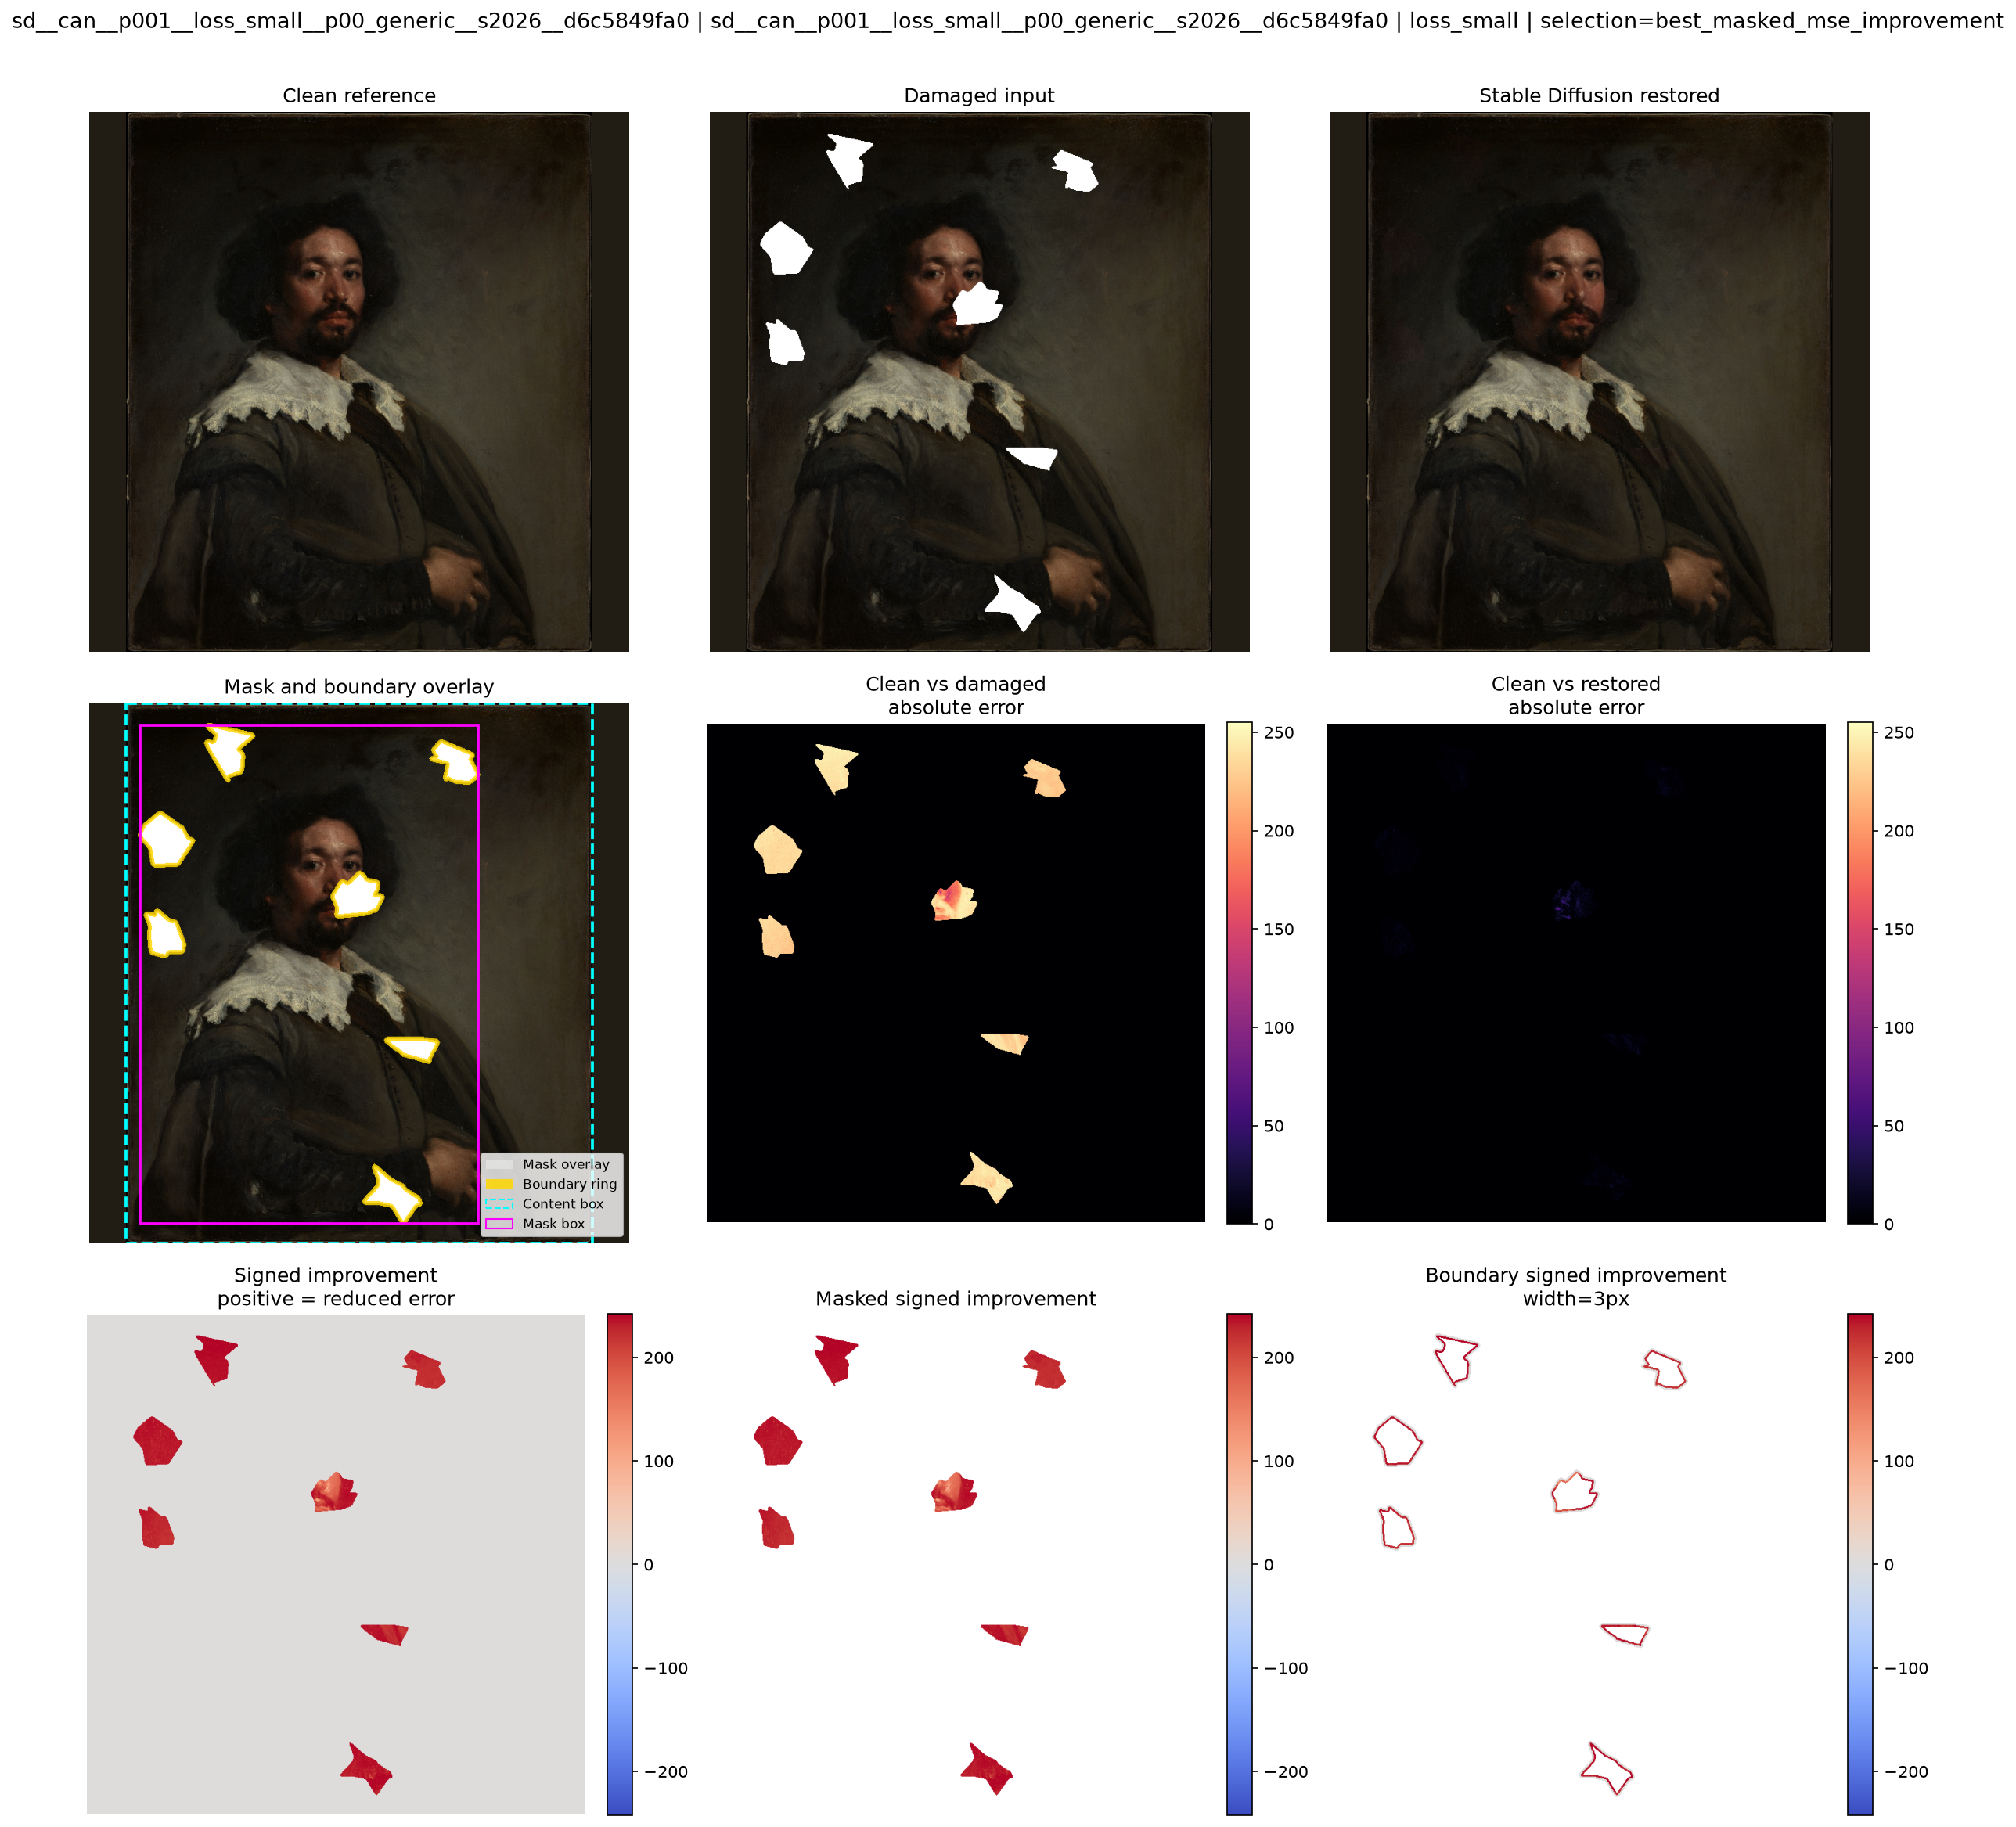

dm_panel_002: sd__mrob__p001__loss_small__p00_generic__s2026__77a0be3062 | best_masked_mse_improvement


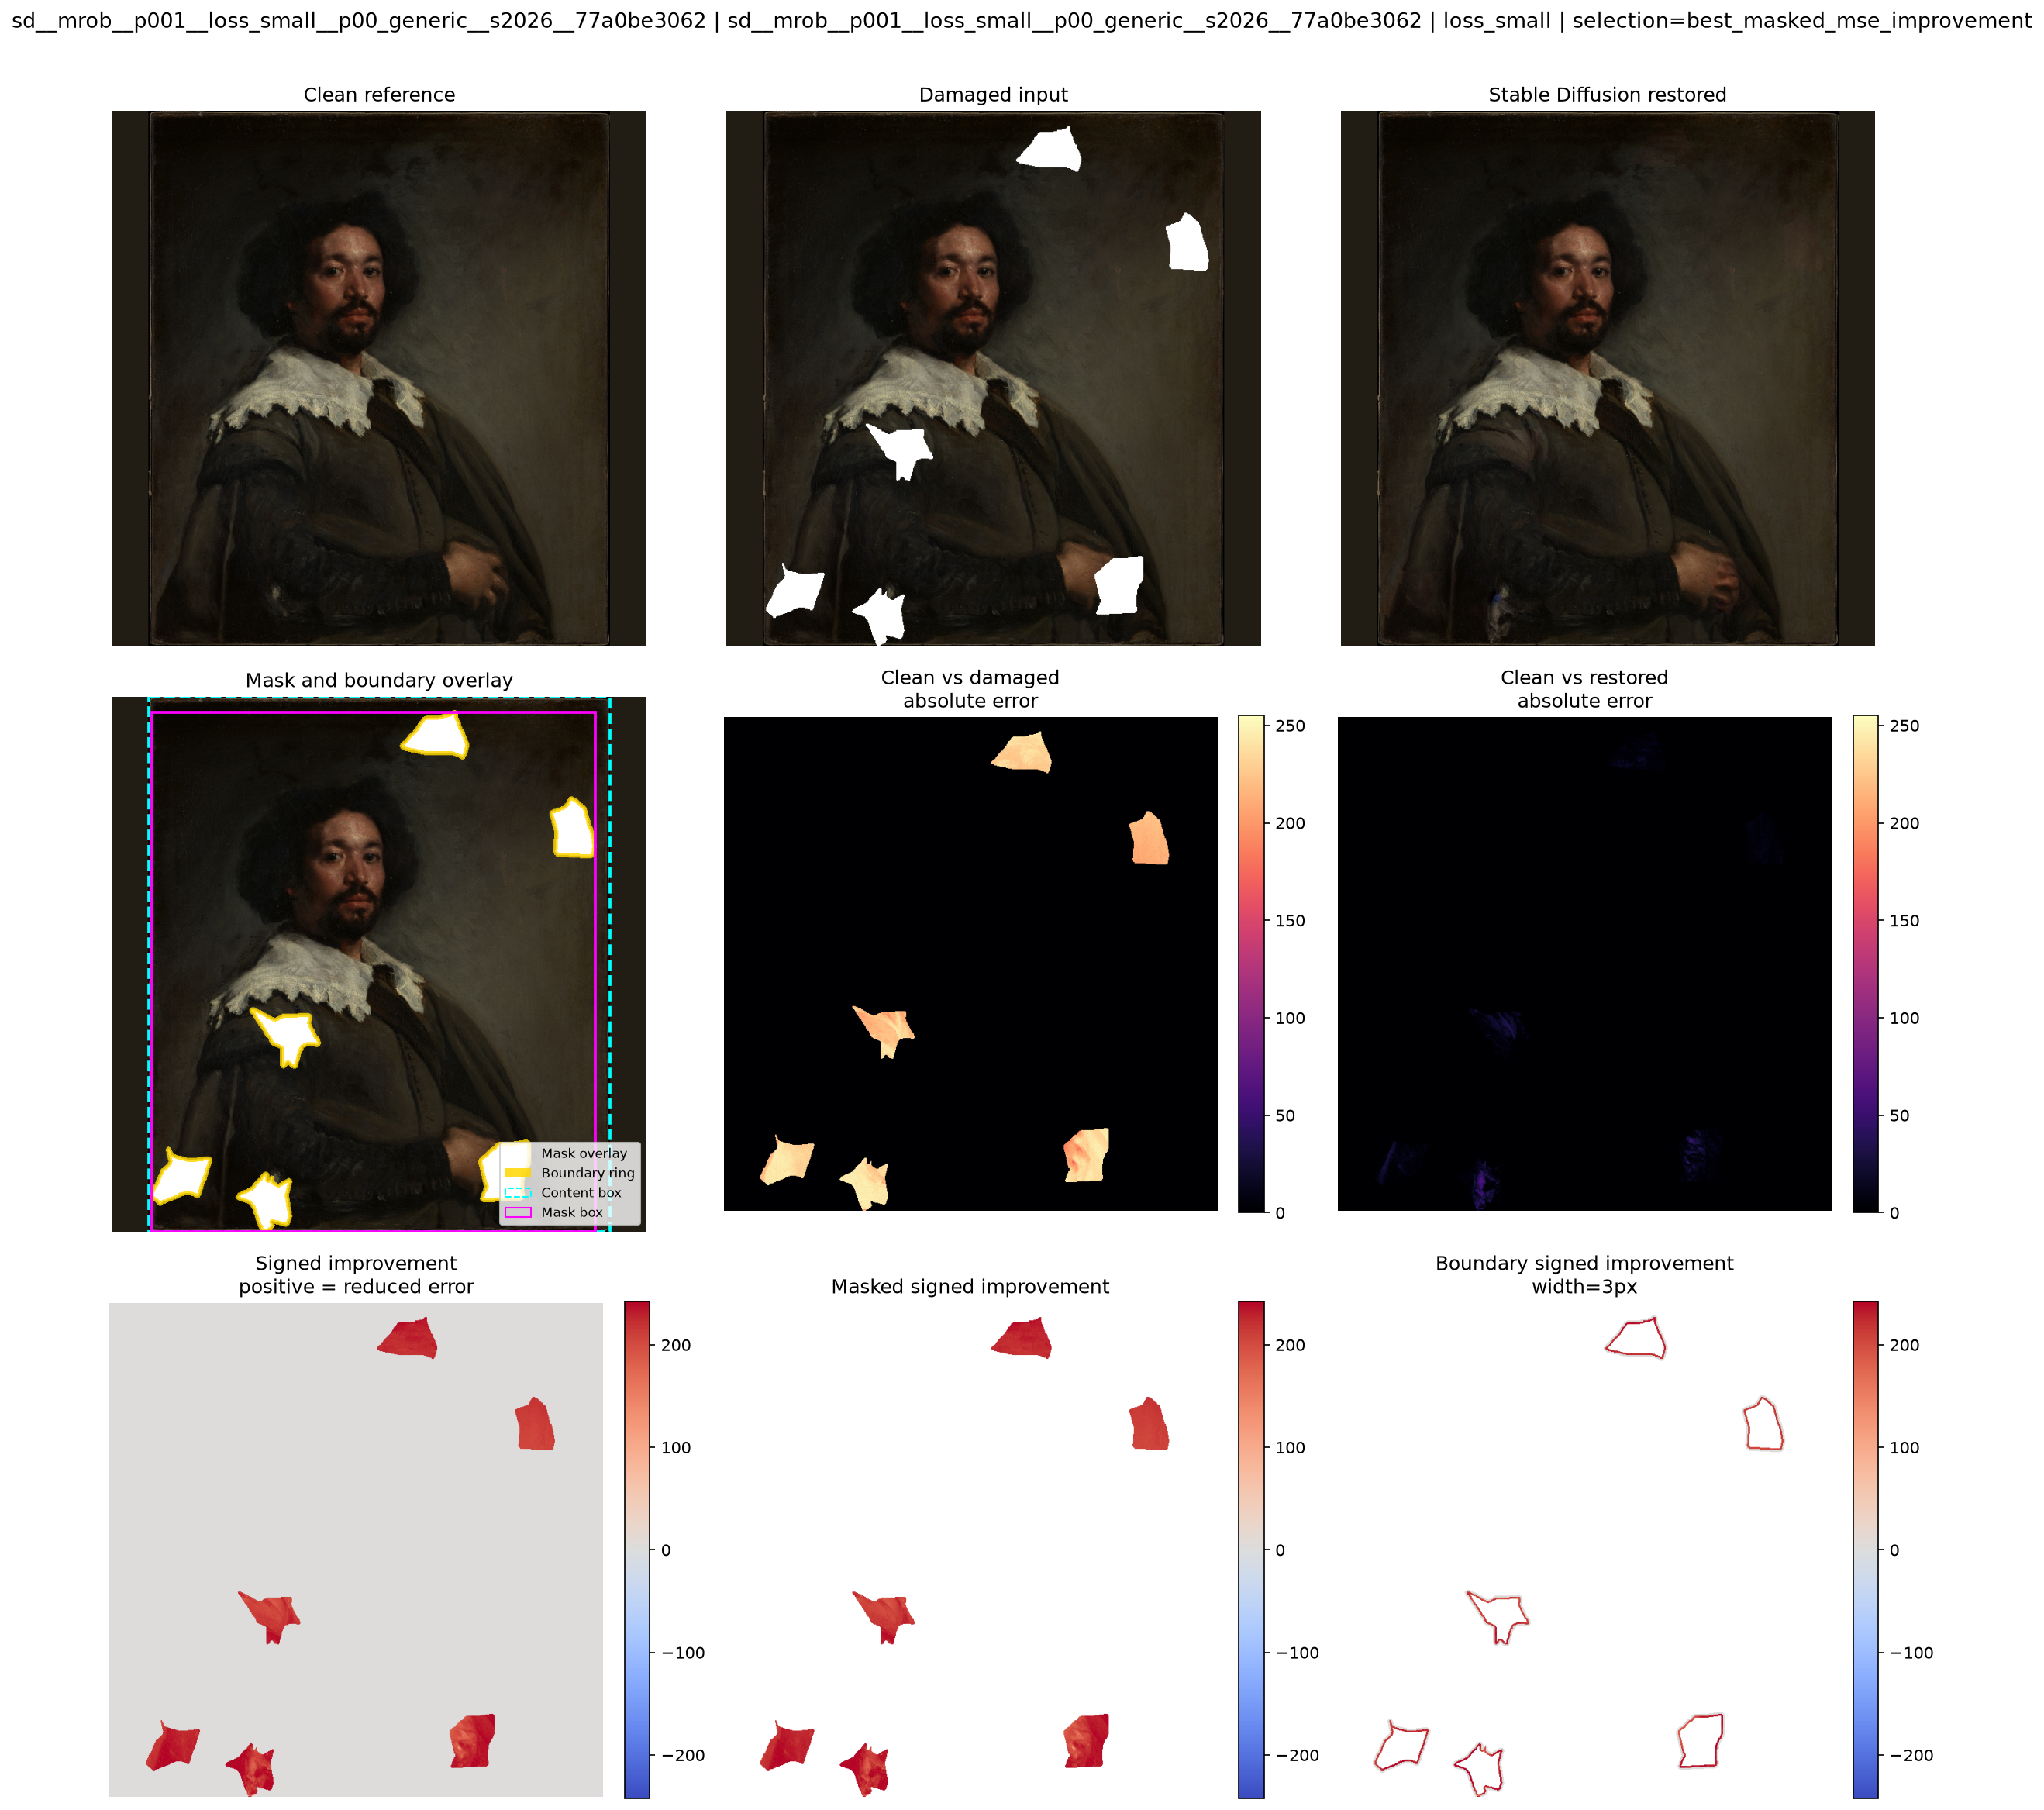

dm_panel_003: sd__can__p036__scratch_thin__p00_generic__s2026__6a92401a07 | weakest_masked_mse_improvement


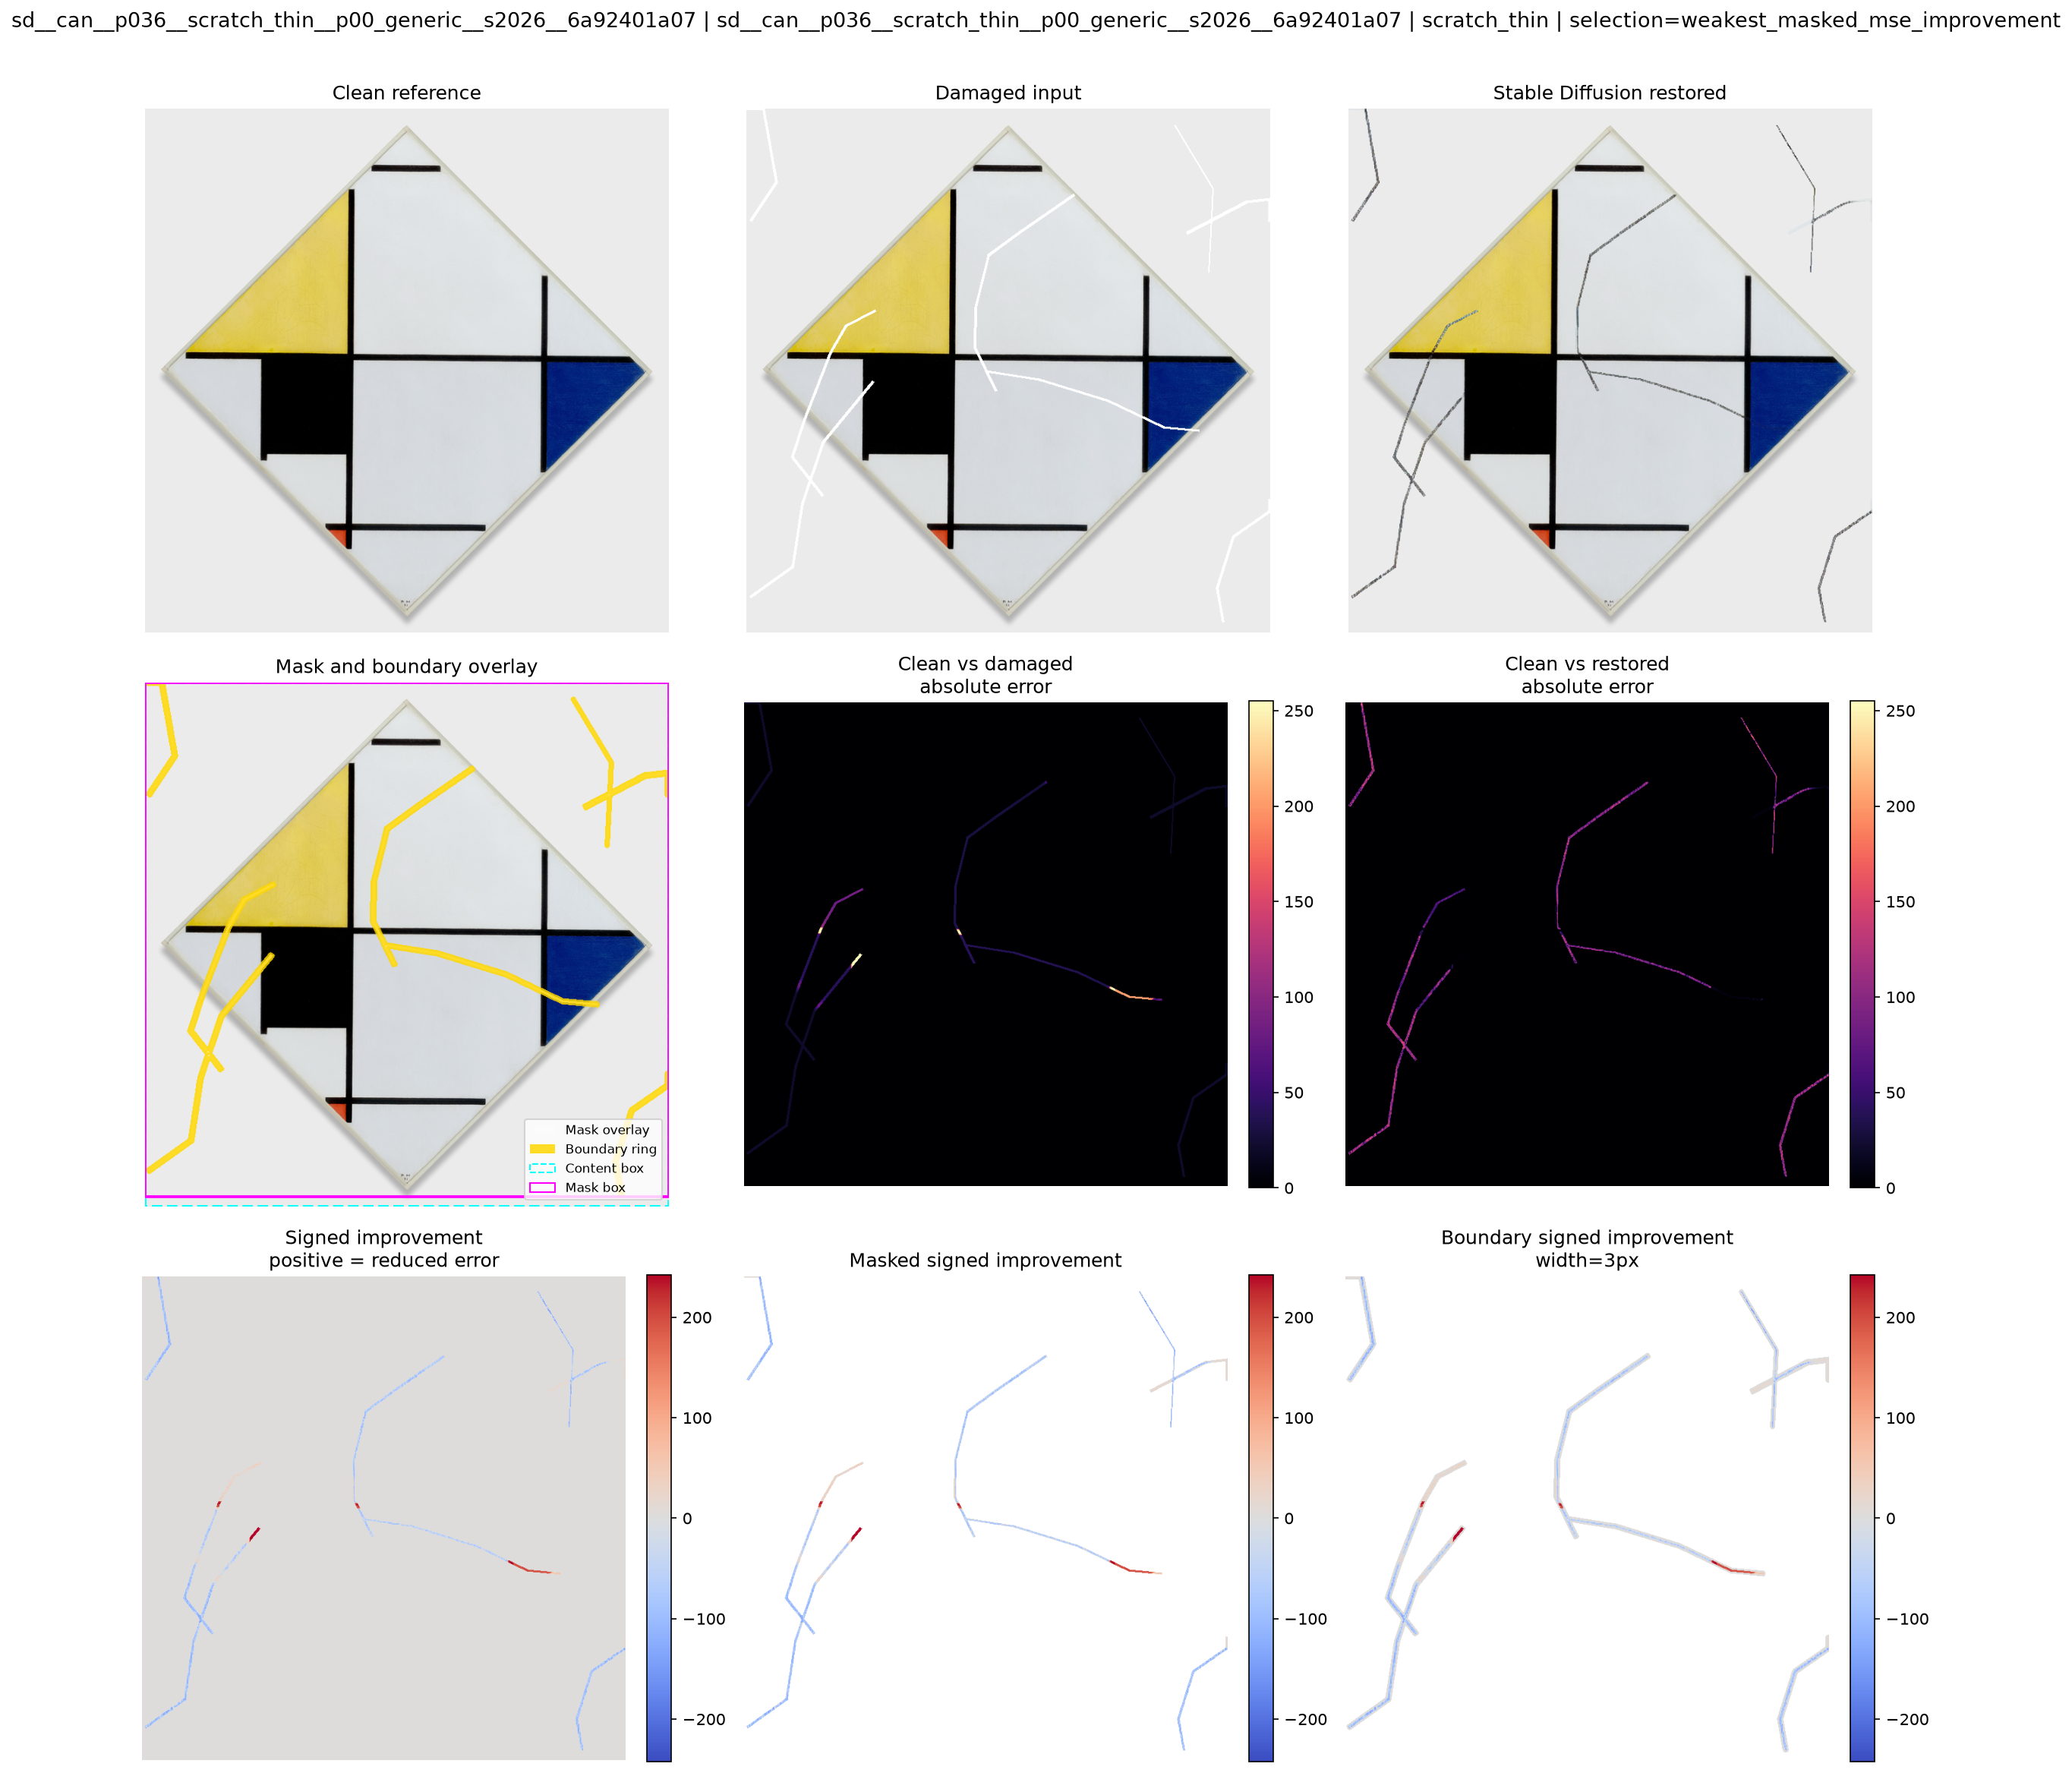

In [21]:
# Batch 3 / Cell 21 - Visual inspect selected panels
NUM_PREVIEW_PANELS = min(3, len(figure_manifest_df))

print(f"Previewing {NUM_PREVIEW_PANELS} selected diagnostic panels.")

for _, row in figure_manifest_df.head(NUM_PREVIEW_PANELS).iterrows():
    figure_path = resolve_project_path(row["figure_path"])
    print(f"{row.get('figure_id', '')}: {row.get('candidate_id', '')} | {row.get('selection_group', '')}")
    ipy_display(IPImage(filename=str(figure_path), width=1000))

In [22]:
# Batch 3 / Cell 22 - Update stage manifest
if STAGE_MANIFEST_PATH.is_file():
    stage_manifest = json.loads(STAGE_MANIFEST_PATH.read_text(encoding="utf-8"))
else:
    stage_manifest = {
        "schema_version": "stable_diffusion_difference_maps_stage_manifest_v1",
        "notebook_id": NOTEBOOK_ID,
        "notebook_label": NOTEBOOK_LABEL,
        "output_root": rel(OUTPUT_ROOT),
    }

stage_manifest["stage"] = "batch3_selected_diagnostic_panels"
stage_manifest["stage_status"] = "passed"
stage_manifest["updated_at_utc"] = utc_now_iso()

stage_manifest["batch3"] = {
    "status": "passed",
    "outputs": {
        "selected_cases": rel(BATCH3_SELECTED_CASES_PATH),
        "figure_manifest": rel(BATCH3_FIGURE_MANIFEST_PATH),
        "selected_panel_dir": rel(BATCH3_FIGURE_DIR),
        "batch3_validation": rel(BATCH3_VALIDATION_PATH),
    },
    "row_counts": {
        "selected_cases": int(len(selected_cases_df)),
        "figure_manifest_rows": int(len(figure_manifest_df)),
    },
    "asset_contract": {
        "selected_richer_panels": True,
        "panel_filename_policy": "short deterministic filenames: dm_panel_001.png",
        "linked_batch2_map_assets": MAP_ASSET_TYPES,
        "panel_count": int(len(figure_manifest_df)),
        "max_panel_filename_length": int(max_panel_filename_length),
    },
    "visual_interpretation_scope": {
        "xai_scope": "spatial diagnostic explainability assets, not model-internal attribution",
        "included_views": [
            "clean reference",
            "damaged input",
            "stable diffusion restored",
            "mask and boundary overlay",
            "clean-vs-damaged absolute error",
            "clean-vs-restored absolute error",
            "signed improvement",
            "masked signed improvement",
            "boundary signed improvement",
        ],
    },
}

STAGE_MANIFEST_PATH.write_text(json.dumps(to_json_safe(stage_manifest), indent=2), encoding="utf-8")

print(f"Updated: {rel(STAGE_MANIFEST_PATH)}")

Updated: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json


In [23]:
# Batch 4 / Cell 23 - Load Batch 3 outputs
BATCH4_SUMMARY_PATH = OUTPUT_DIRS["analysis"] / "stable_diffusion_difference_map_summary.csv"
BATCH4_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch4_analysis_validation.csv"

if "BATCH3_SELECTED_CASES_PATH" not in globals():
    BATCH3_SELECTED_CASES_PATH = OUTPUT_DIRS["analysis"] / "stable_diffusion_difference_map_selected_cases.csv"

if "BATCH3_FIGURE_MANIFEST_PATH" not in globals():
    BATCH3_FIGURE_MANIFEST_PATH = OUTPUT_DIRS["figures"] / "stable_diffusion_difference_map_figure_manifest.csv"

if "BATCH3_VALIDATION_PATH" not in globals():
    BATCH3_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch3_selected_figures_validation.csv"

if "BATCH2_AUDIT_PATH" not in globals():
    BATCH2_AUDIT_PATH = OUTPUT_DIRS["metrics"] / "stable_diffusion_difference_map_audit.csv"

if "BATCH2_IMAGE_MANIFEST_PATH" not in globals():
    BATCH2_IMAGE_MANIFEST_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_map_image_manifest.csv"

batch2_audit_df = pd.read_csv(BATCH2_AUDIT_PATH)
batch2_image_manifest_df = pd.read_csv(BATCH2_IMAGE_MANIFEST_PATH)
batch3_selected_cases_df = pd.read_csv(BATCH3_SELECTED_CASES_PATH)
batch3_figure_manifest_df = pd.read_csv(BATCH3_FIGURE_MANIFEST_PATH)
batch3_validation_df = pd.read_csv(BATCH3_VALIDATION_PATH)

batch3_passed = (
    not batch3_validation_df.empty
    and "passed" in batch3_validation_df.columns
    and bool_series(batch3_validation_df["passed"]).all()
)

if not batch3_passed:
    raise RuntimeError("Batch 3 validation has not passed. Do not run Batch 4 yet.")

print(f"Batch 2 audit rows: {len(batch2_audit_df):,}")
print(f"Batch 3 selected rows: {len(batch3_selected_cases_df):,}")
print(f"Batch 3 figure rows: {len(batch3_figure_manifest_df):,}")
print(f"Batch 3 validation passed: {batch3_passed}")

Batch 2 audit rows: 945
Batch 3 selected rows: 11
Batch 3 figure rows: 11
Batch 3 validation passed: True


In [27]:
# Batch 4 / Cell 24 - Build compact ranked analysis table
ANALYSIS_THRESHOLDS = {
    "mostly_improved_negative_percentage_max": 5.0,
    "mixed_negative_percentage_min": 20.0,
    "likely_harmful_negative_percentage_min": 50.0,
    "near_zero_improvement_abs_max": 0.25,
}

compact_analysis_df = batch2_audit_df.copy()

if "status" in compact_analysis_df.columns:
    compact_analysis_df = compact_analysis_df.rename(
        columns={
            "status": "map_asset_status",
            "issue": "map_asset_issue",
        }
    )

selected_lookup_columns = [
    "map_id",
    "figure_id",
    "figure_filename",
    "figure_path",
    "panel_status",
    "panel_issue",
    "selection_group",
    "inspection_note",
]

selected_lookup_columns = [
    column for column in selected_lookup_columns
    if column in batch3_selected_cases_df.columns
]

selected_lookup_df = (
    batch3_selected_cases_df[selected_lookup_columns]
    .drop_duplicates("map_id", keep="first")
    .copy()
)

compact_analysis_df = compact_analysis_df.merge(
    selected_lookup_df,
    on="map_id",
    how="left",
    suffixes=("", "_selected"),
)

compact_analysis_df["is_selected_for_report"] = compact_analysis_df["map_id"].isin(
    set(batch3_selected_cases_df["map_id"].astype(str))
)

numeric_metric_columns = [
    "damaged_error_mean_full",
    "restored_error_mean_full",
    "improvement_mean_full",
    "damaged_error_mean_masked",
    "restored_error_mean_masked",
    "improvement_mean_masked",
    "negative_improvement_percentage_masked",
    "positive_improvement_percentage_masked",
    "improvement_boundary_mean",
    "improvement_boundary_negative_percentage",
    "improvement_outside_mask_mean",
    "improvement_content_mean",
    "masked_pixel_count",
    "boundary_pixel_count",
]

numeric_metric_columns = [
    column for column in numeric_metric_columns
    if column in compact_analysis_df.columns
]

for column in numeric_metric_columns:
    compact_analysis_df[column] = pd.to_numeric(compact_analysis_df[column], errors="coerce")

if {
    "damaged_error_mean_masked",
    "restored_error_mean_masked",
}.issubset(compact_analysis_df.columns):
    compact_analysis_df["masked_error_reduction_mean"] = (
        compact_analysis_df["damaged_error_mean_masked"]
        - compact_analysis_df["restored_error_mean_masked"]
    )

if "improvement_outside_mask_mean" in compact_analysis_df.columns:
    compact_analysis_df["outside_mask_abs_improvement_mean"] = (
        compact_analysis_df["improvement_outside_mask_mean"].abs()
    )

compact_analysis_df["masked_improvement_rank_desc"] = (
    compact_analysis_df["improvement_mean_masked"]
    .rank(method="min", ascending=False)
    .astype("Int64")
)

compact_analysis_df["restored_error_rank_asc"] = (
    compact_analysis_df["restored_error_mean_masked"]
    .rank(method="min", ascending=True)
    .astype("Int64")
)

compact_analysis_df["masked_harm_rank_desc"] = (
    compact_analysis_df["negative_improvement_percentage_masked"]
    .rank(method="min", ascending=False)
    .astype("Int64")
)

if "improvement_boundary_mean" in compact_analysis_df.columns:
    compact_analysis_df["boundary_improvement_rank_desc"] = (
        compact_analysis_df["improvement_boundary_mean"]
        .rank(method="min", ascending=False)
        .astype("Int64")
    )

if "outside_mask_abs_improvement_mean" in compact_analysis_df.columns:
    compact_analysis_df["outside_mask_change_rank_desc"] = (
        compact_analysis_df["outside_mask_abs_improvement_mean"]
        .rank(method="min", ascending=False)
        .astype("Int64")
    )

compact_analysis_df["map_outcome_label"] = np.select(
    [
        (
            compact_analysis_df["improvement_mean_masked"].le(0)
            | compact_analysis_df["negative_improvement_percentage_masked"].ge(
                ANALYSIS_THRESHOLDS["likely_harmful_negative_percentage_min"]
            )
        ),
        compact_analysis_df["negative_improvement_percentage_masked"].ge(
            ANALYSIS_THRESHOLDS["mixed_negative_percentage_min"]
        ),
        (
            compact_analysis_df["improvement_mean_masked"].abs().le(
                ANALYSIS_THRESHOLDS["near_zero_improvement_abs_max"]
            )
        ),
        (
            compact_analysis_df["improvement_mean_masked"].gt(0)
            & compact_analysis_df["negative_improvement_percentage_masked"].le(
                ANALYSIS_THRESHOLDS["mostly_improved_negative_percentage_max"]
            )
        ),
    ],
    [
        "likely_harmful_or_failed",
        "mixed_local_effects",
        "near_neutral",
        "mostly_improved",
    ],
    default="improved_with_residual_harm",
)

outcome_priority_map = {
    "likely_harmful_or_failed": 1,
    "mixed_local_effects": 2,
    "improved_with_residual_harm": 3,
    "near_neutral": 4,
    "mostly_improved": 5,
}

compact_analysis_df["outcome_priority"] = compact_analysis_df["map_outcome_label"].map(
    outcome_priority_map
)

compact_analysis_df = compact_analysis_df.sort_values(
    [
        "is_selected_for_report",
        "outcome_priority",
        "masked_harm_rank_desc",
        "masked_improvement_rank_desc",
        "map_index",
    ],
    ascending=[False, True, True, True, True],
).reset_index(drop=True)

compact_analysis_df.insert(0, "review_priority_rank", range(1, len(compact_analysis_df) + 1))
compact_analysis_df.insert(1, "summary_scope", "candidate_difference_map_analysis")

preferred_columns = [
    "summary_scope",
    "review_priority_rank",
    "map_id",
    "map_index",
    "candidate_id",
    "is_selected_for_report",
    "selected_case_index",
    "selection_group",
    "map_outcome_label",
    "outcome_priority",
    "masked_improvement_rank_desc",
    "restored_error_rank_asc",
    "masked_harm_rank_desc",
    "boundary_improvement_rank_desc",
    "outside_mask_change_rank_desc",
    "damaged_error_mean_masked",
    "restored_error_mean_masked",
    "masked_error_reduction_mean",
    "improvement_mean_masked",
    "positive_improvement_percentage_masked",
    "negative_improvement_percentage_masked",
    "improvement_boundary_mean",
    "improvement_boundary_negative_percentage",
    "improvement_outside_mask_mean",
    "outside_mask_abs_improvement_mean",
    "improvement_content_mean",
    "masked_pixel_count",
    "boundary_pixel_count",
    "dataset_name",
    "case_id",
    "restoration_case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "category",
    "title",
    "artist",
    "degradation_type",
    "severity",
    "figure_id",
    "figure_filename",
    "figure_path",
    "map_asset_status",
    "map_asset_issue",
]

preferred_columns = [
    column for column in preferred_columns
    if column in compact_analysis_df.columns
]

remaining_columns_to_keep = [
    column for column in compact_analysis_df.columns
    if column not in preferred_columns
    and (
        column.endswith("_path")
        or column.endswith("_filename")
        or column in ["clean_path", "damaged_path", "mask_path", "restored_path"]
    )
]

compact_analysis_df = compact_analysis_df[
    preferred_columns + remaining_columns_to_keep
].copy()

compact_analysis_df.to_csv(BATCH4_SUMMARY_PATH, index=False)

print(f"Saved: {rel(BATCH4_SUMMARY_PATH)}")
print(f"Compact analysis rows: {len(compact_analysis_df):,}")
display(compact_analysis_df.head(15))

Saved: outputs/23_stable_diffusion_difference_maps/analysis/stable_diffusion_difference_map_summary.csv
Compact analysis rows: 945


,summary_scope,review_priority_rank,map_id,map_index,candidate_id,is_selected_for_report,selection_group,map_outcome_label,outcome_priority,masked_improvement_rank_desc,...,signed_improvement_map_path,signed_improvement_map_filename,masked_signed_improvement_map_path,masked_signed_improvement_map_filename,boundary_signed_improvement_map_path,boundary_signed_improvement_map_filename,mask_overlay_path,mask_overlay_filename,boundary_overlay_path,boundary_overlay_filename
0,candidate_difference_map_analysis,1,dm_000888,888,sd__syn__p039__water_stain__p04_full_context__...,True,weakest_masked_mse_improvement,likely_harmful_or_failed,1,850,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000888_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000888_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000888_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000888_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000888_bnd.png
1,candidate_difference_map_analysis,2,dm_000327,327,sd__can__p036__scratch_thin__p00_generic__s202...,True,weakest_masked_mse_improvement,likely_harmful_or_failed,1,851,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000327_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000327_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000327_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000327_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000327_bnd.png
2,candidate_difference_map_analysis,3,dm_000005,5,sd__can__p001__zero__p00_generic__s2026__3be10...,True,zero_control_largest_restored_shift,improved_with_residual_harm,3,<NA>,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000005_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000005_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000005_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000005_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000005_bnd.png
3,candidate_difference_map_analysis,4,dm_000010,10,sd__can__p002__zero__p00_generic__s2026__606dc...,True,zero_control_largest_restored_shift,improved_with_residual_harm,3,<NA>,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000010_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000010_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000010_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000010_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000010_bnd.png
4,candidate_difference_map_analysis,5,dm_000364,364,sd__can__p040__loss_large__p00_generic__s2026_...,True,category_representative_best_masked_mse,mostly_improved,5,268,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000364_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000364_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000364_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000364_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000364_bnd.png
5,candidate_difference_map_analysis,6,dm_000165,165,sd__can__p018__scratch_thin__p04_full_context_...,True,category_representative_best_masked_mse,mostly_improved,5,50,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000165_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000165_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000165_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000165_msk.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000165_bnd.png
6,candidate_difference_map_analysis,7,dm_000201,201,sd__can__p024__loss_small__p00_generic__s2026_...,True,category_representative_best_masked_mse,mostly_improved,5,34,...,outputs/23_stable_diffusion_difference_maps/ma...,dm_000201_sig.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000201_msi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000201_bsi.png,outputs/23_stable_diffusion_difference_maps/ma...,dm_000201

In [28]:
# Batch 4 / Cell 24B - Fix zero-control/no-mask metric handling
compact_analysis_df["masked_pixel_count"] = pd.to_numeric(
    compact_analysis_df.get("masked_pixel_count", np.nan),
    errors="coerce",
)

compact_analysis_df["has_masked_region"] = compact_analysis_df["masked_pixel_count"].fillna(0).gt(0)

masked_metric_columns = [
    "improvement_mean_masked",
    "negative_improvement_percentage_masked",
    "positive_improvement_percentage_masked",
    "restored_error_mean_masked",
    "damaged_error_mean_masked",
]

for column in masked_metric_columns:
    if column in compact_analysis_df.columns:
        compact_analysis_df[column] = pd.to_numeric(compact_analysis_df[column], errors="coerce")

zero_control_mask = ~compact_analysis_df["has_masked_region"]

compact_analysis_df.loc[zero_control_mask, "map_outcome_label"] = "zero_control_no_mask"
compact_analysis_df.loc[zero_control_mask, "outcome_priority"] = 6

compact_analysis_df.to_csv(BATCH4_SUMMARY_PATH, index=False)

print(f"Updated zero-control handling in: {rel(BATCH4_SUMMARY_PATH)}")
print(f"Rows without masked region: {int(zero_control_mask.sum()):,}")
display(
    compact_analysis_df.loc[
        zero_control_mask,
        [
            "review_priority_rank",
            "map_id",
            "candidate_id",
            "map_outcome_label",
            "masked_pixel_count",
            "improvement_mean_masked",
            "negative_improvement_percentage_masked",
        ],
    ].head(10)
)

Updated zero-control handling in: outputs/23_stable_diffusion_difference_maps/analysis/stable_diffusion_difference_map_summary.csv
Rows without masked region: 94


,review_priority_rank,map_id,candidate_id,map_outcome_label,masked_pixel_count,improvement_mean_masked,negative_improvement_percentage_masked
2,3,dm_000005,sd__can__p001__zero__p00_generic__s2026__3be10...,zero_control_no_mask,0,NaN,NaN
3,4,dm_000010,sd__can__p002__zero__p00_generic__s2026__606dc...,zero_control_no_mask,0,NaN,NaN
343,344,dm_000015,sd__can__p003__zero__p00_generic__s2026__b541c...,zero_control_no_mask,0,NaN,NaN
344,345,dm_000036,sd__can__p004__zero__p00_generic__s2026__f5472...,zero_control_no_mask,0,NaN,NaN
345,346,dm_000037,sd__can__p004__zero__p01_style_period__s2026__...,zero_control_no_mask,0,NaN,NaN
346,347,dm_000038,sd__can__p004__zero__p02_artist__s2026__ff4143...,zero_control_no_mask,0,NaN,NaN
347,348,dm_000039,sd__can__p004__zero__p03_artist_style_p__s2026...,zero_control_no_mask,0,NaN,NaN
348,349,dm_000040,sd__can__p004__zero__p04_full_context__s2026__...,zero_control_no_mask,0,NaN,NaN
349,350,dm_000045,sd__can__p005__zero__p00_generic__s2026__721e5...,zero_control_no_mask,0,NaN,NaN
350,351,dm_000050,sd__can__p006__zero__p00_generic__s2026__673d8...,zero_control_no_mask,0,NaN,NaN


In [29]:
# Batch 4 / Cell 25 - In-notebook summaries and rankings
summary_metric_columns = [
    "improvement_mean_masked",
    "negative_improvement_percentage_masked",
    "positive_improvement_percentage_masked",
    "restored_error_mean_masked",
    "improvement_boundary_mean",
    "improvement_outside_mask_mean",
]

summary_metric_columns = [
    column for column in summary_metric_columns
    if column in compact_analysis_df.columns
]

global_summary_df = compact_analysis_df[summary_metric_columns].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T.reset_index()

global_summary_df = global_summary_df.rename(columns={"index": "metric"})

outcome_counts_df = (
    compact_analysis_df["map_outcome_label"]
    .value_counts(dropna=False)
    .rename_axis("map_outcome_label")
    .reset_index(name="case_count")
)

outcome_counts_df["case_percentage"] = (
    outcome_counts_df["case_count"] / len(compact_analysis_df) * 100.0
)

print("Global metric summary")
display(global_summary_df)

print("Outcome label counts")
display(outcome_counts_df)

group_summary_frames = []

for group_column in ["mask_type", "category", "severity", "dataset_name"]:
    if group_column not in compact_analysis_df.columns:
        continue

    group_df = (
        compact_analysis_df
        .groupby(group_column, dropna=False)[summary_metric_columns]
        .agg(["count", "mean", "median", "min", "max"])
        .reset_index()
    )

    group_df.columns = [
        "_".join([str(part) for part in column if str(part)])
        if isinstance(column, tuple)
        else str(column)
        for column in group_df.columns
    ]

    group_df.insert(0, "grouping_column", group_column)
    group_summary_frames.append(group_df)

if group_summary_frames:
    grouped_summary_df = pd.concat(group_summary_frames, ignore_index=True, sort=False)
    print("Grouped summaries")
    display(grouped_summary_df.head(50))
else:
    grouped_summary_df = pd.DataFrame()
    print("No grouping columns available for grouped summaries.")

top_improved_df = compact_analysis_df.sort_values(
    "masked_improvement_rank_desc"
).head(10)

most_harm_df = compact_analysis_df.sort_values(
    "masked_harm_rank_desc"
).head(10)

lowest_restored_error_df = compact_analysis_df.sort_values(
    "restored_error_rank_asc"
).head(10)

display_columns = [
    column for column in [
        "review_priority_rank",
        "map_id",
        "candidate_id",
        "map_outcome_label",
        "is_selected_for_report",
        "mask_type",
        "category",
        "improvement_mean_masked",
        "negative_improvement_percentage_masked",
        "restored_error_mean_masked",
        "figure_path",
    ]
    if column in compact_analysis_df.columns
]

print("Top 10 masked improvements")
display(top_improved_df[display_columns])

print("Top 10 masked harm / regression cases")
display(most_harm_df[display_columns])

print("Top 10 lowest restored masked error")
display(lowest_restored_error_df[display_columns])

Global metric summary


,metric,count,mean,median,std,min,max
0,improvement_mean_masked,851.0,84.126733,109.571106,73.006383,-38.987049,227.298172
1,negative_improvement_percentage_masked,851.0,12.096136,1.406174,19.279278,0.000000,98.538127
2,positive_improvement_percentage_masked,851.0,66.902130,98.325567,44.193540,0.000000,100.000000
3,restored_error_mean_masked,851.0,23.346012,22.051464,13.795526,0.355178,89.835426
4,improvement_boundary_mean,851.0,40.149556,46.396297,33.666025,-15.617237,110.830505
5,improvement_outside_mask_mean,945.0,0.000000,0.000000,0.000000,0.000000,0.000000


Outcome label counts


,map_outcome_label,case_count,case_percentage
0,mostly_improved,516,54.603175
1,likely_harmful_or_failed,289,30.582011
2,zero_control_no_mask,94,9.947090
3,improved_with_residual_harm,42,4.444444
4,mixed_local_effects,3,0.317460
5,near_neutral,1,0.105820


Grouped summaries


...

,review_priority_rank,map_id,candidate_id,map_outcome_label,is_selected_for_report,mask_type,category,improvement_mean_masked,negative_improvement_percentage_masked,restored_error_mean_masked,figure_path
7,8,dm_000002,sd__can__p001__loss_small__p00_generic__s2026_...,mostly_improved,True,loss_small,portrait_figure,227.298172,0.000000,5.175668,outputs/23_stable_diffusion_difference_maps/fi...
8,9,dm_000525,sd__mrob__p001__loss_small__p00_generic__s2026...,mostly_improved,True,loss_small,portrait_figure,220.491226,0.000000,8.718511,outputs/23_stable_diffusion_difference_maps/fi...
780,781,dm_000526,sd__mrob__p001__loss_small__p00_generic__s2026...,mostly_improved,False,loss_small,portrait_figure,217.170166,0.043622,7.010193,NaN
856,857,dm_000529,sd__mrob__p001__loss_small__p02_artist__s2026_...,mostly_improved,False,loss_small,portrait_figure,217.117737,0.000000,6.645648,NaN
857,858,dm_000530,sd__mrob__p001__loss_small__p03_artist_style_p...,mostly_improved,False,loss_small,portrait_figure,217.077728,0.000000,6.685663,NaN
858,859,dm_000047,sd__can__p006__loss_small__p00_generic__s2026_...,mostly_improved,False,loss_small,portrait_figure,217.052246,0.000000,4.155440,NaN
859,860,dm_000531,sd__mrob__p001__loss_small__p04_full_context__...,mostly_improved,False,loss_small,portrait_figure,217.042267,0.000000,6.721135,NaN
860,861,dm_000528,sd__mrob__p001__loss_small__p01_style_period__...,mostly_improved,False,loss_small,portrait_figure,216.923584,0.000000,6.839797,NaN
861,862,dm_000527,sd__mrob__p001__loss_small__p00_generic__s2026...,mostly_improved,False,loss_small,portrait_figure,216.768280,0.000000,6.995109,NaN
862,863,dm_000046,sd__can__p006__loss_large__p00_generic__s2026_...,mostly_improved,False,loss_large,portrait_figure,211.966858,0.000000,7.818331,NaN


Top 10 masked harm / regression cases


,review_priority_rank,map_id,candidate_id,map_outcome_label,is_selected_for_report,mask_type,category,improvement_mean_masked,negative_improvement_percentage_masked,restored_error_mean_masked,figure_path
11,12,dm_000826,sd__syn__p026__water_stain__p00_generic__s2026...,likely_harmful_or_failed,False,water_stain,architecture_structured,-24.060835,98.538127,26.596220,NaN
0,1,dm_000888,sd__syn__p039__water_stain__p04_full_context__...,likely_harmful_or_failed,True,water_stain,abstraction_surrealism,-33.737743,95.504116,41.296150,outputs/23_stable_diffusion_difference_maps/fi...
12,13,dm_000886,sd__syn__p039__water_stain__p02_artist__s2026_...,likely_harmful_or_failed,False,water_stain,abstraction_surrealism,-29.673695,92.842279,37.232098,NaN
13,14,dm_000831,sd__syn__p026__water_stain__p04_full_context__...,likely_harmful_or_failed,False,water_stain,architecture_structured,-17.825912,92.783358,23.595093,NaN
14,15,dm_000828,sd__syn__p026__water_stain__p01_style_period__...,likely_harmful_or_failed,False,water_stain,architecture_structured,-16.850212,92.035580,22.619394,NaN
15,16,dm_000827,sd__syn__p026__water_stain__p00_generic__s2026...,likely_harmful_or_failed,False,water_stain,architecture_structured,-16.766951,92.031123,22.536127,NaN
16,17,dm_000940,sd__syn__p043__water_stain__p00_generic__s2026...,likely_harmful_or_failed,False,water_stain,high_texture_brushwork,-27.709778,92.006138,32.183563,NaN
17,18,dm_000830,sd__syn__p026__water_stain__p03_artist_style_p...,likely_harmful_or_failed,False,water_stain,architecture_structured,-17.109226,91.948235,22.878408,NaN
18,19,dm_000829,sd__syn__p026__water_stain__p02_artist__s2026_...,likely_harmful_or_failed,False,water_stain,architecture_structured,-16.558262,91.666592,22.327442,NaN
19,20,dm_000885,sd__syn__p039__water_stain__p01_style_period__...,likely_harmful_or_failed,False,water_stain,abstraction_surrealism,-25.759886,91.640435,33.318287,NaN


Top 10 lowest restored masked error


,review_priority_rank,map_id,candidate_id,map_outcome_label,is_selected_for_report,mask_type,category,improvement_mean_masked,negative_improvement_percentage_masked,restored_error_mean_masked,figure_path
295,296,dm_000844,sd__syn__p039__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,abstraction_surrealism,-0.341156,0.973599,0.355178,NaN
296,297,dm_000901,sd__syn__p043__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,high_texture_brushwork,-0.374098,0.953208,0.377684,NaN
289,290,dm_000783,sd__syn__p026__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,architecture_structured,-0.499481,1.726519,0.515252,NaN
297,298,dm_000669,sd__syn__p001__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,portrait_figure,-0.801831,0.947234,0.802374,NaN
287,288,dm_000784,sd__syn__p026__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,architecture_structured,-1.105933,2.980425,1.215933,NaN
288,289,dm_000726,sd__syn__p018__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,landscape_natural,-1.231152,2.183639,1.236839,NaN
285,286,dm_000902,sd__syn__p043__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,high_texture_brushwork,-1.256932,3.319040,1.390873,NaN
284,285,dm_000845,sd__syn__p039__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,abstraction_surrealism,-1.439263,3.884371,1.658346,NaN
269,270,dm_000903,sd__syn__p043__dirt_dust__p00_generic__s2026__...,likely_harmful_or_failed,False,dirt_dust,high_texture_brushwork,-1.510544,6.048277,1.966708,NaN
268,269,dm_000904,sd__syn__p043__dirt_dust__p01_style_period__s2...,likely_harmful_or_failed,False,dirt_dust,high_texture_brushwork,-1.518084,6.057985,1.974248,NaN


In [30]:
# Batch 4 / Cell 26 - Validate compact analysis table
expected_candidate_count = 945
expected_selected_count = 11

required_summary_columns = [
    "summary_scope",
    "review_priority_rank",
    "map_id",
    "candidate_id",
    "is_selected_for_report",
    "map_outcome_label",
    "improvement_mean_masked",
    "negative_improvement_percentage_masked",
    "masked_improvement_rank_desc",
    "restored_error_rank_asc",
    "masked_harm_rank_desc",
    "has_masked_region",
]

missing_summary_columns = [
    column for column in required_summary_columns
    if column not in compact_analysis_df.columns
]

valid_masked_rows = compact_analysis_df["has_masked_region"].astype(bool)

core_numeric_columns = [
    column for column in [
        "improvement_mean_masked",
        "negative_improvement_percentage_masked",
        "positive_improvement_percentage_masked",
        "restored_error_mean_masked",
        "masked_improvement_rank_desc",
        "restored_error_rank_asc",
        "masked_harm_rank_desc",
    ]
    if column in compact_analysis_df.columns
]

core_numeric_values_finite_for_masked_rows = bool(
    np.isfinite(
        compact_analysis_df.loc[valid_masked_rows, core_numeric_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    ).all()
)

zero_control_rows_have_expected_label = bool(
    compact_analysis_df.loc[
        ~valid_masked_rows,
        "map_outcome_label",
    ].astype(str).eq("zero_control_no_mask").all()
)

review_ranks_unique = compact_analysis_df["review_priority_rank"].is_unique
review_ranks_complete = set(compact_analysis_df["review_priority_rank"].astype(int)) == set(
    range(1, len(compact_analysis_df) + 1)
)

selected_case_count = int(compact_analysis_df["is_selected_for_report"].sum())

if "map_asset_status" in compact_analysis_df.columns:
    non_ok_map_asset_rows = int(compact_analysis_df["map_asset_status"].astype(str).ne("ok").sum())
else:
    non_ok_map_asset_rows = 0

batch4_validation_rows = [
    validation_row(
        "batch3_validation_passed",
        batch3_passed,
        True,
        batch3_passed,
        "Batch 3 validation did not pass.",
    ),
    validation_row(
        "summary_required_columns_present",
        missing_summary_columns,
        [],
        len(missing_summary_columns) == 0,
        "Compact analysis table is missing required columns.",
    ),
    validation_row(
        "summary_row_count",
        len(compact_analysis_df),
        expected_candidate_count,
        len(compact_analysis_df) == expected_candidate_count,
        "Compact analysis table row count does not match all-candidate contract.",
    ),
    validation_row(
        "map_ids_unique",
        int(compact_analysis_df["map_id"].duplicated().sum()),
        0,
        int(compact_analysis_df["map_id"].duplicated().sum()) == 0,
        "Compact analysis table contains duplicate map IDs.",
    ),
    validation_row(
        "candidate_ids_unique",
        int(compact_analysis_df["candidate_id"].duplicated().sum()),
        0,
        int(compact_analysis_df["candidate_id"].duplicated().sum()) == 0,
        "Compact analysis table contains duplicate candidate IDs.",
    ),
    validation_row(
        "selected_case_count",
        selected_case_count,
        expected_selected_count,
        selected_case_count == expected_selected_count,
        "Selected case count does not match the selected-case contract.",
    ),
    validation_row(
        "core_numeric_values_finite_for_masked_rows",
        core_numeric_values_finite_for_masked_rows,
        True,
        core_numeric_values_finite_for_masked_rows,
        "One or more core numeric analysis values is missing/non-finite for rows with a masked region.",
    ),
    validation_row(
        "zero_control_rows_have_expected_label",
        zero_control_rows_have_expected_label,
        True,
        zero_control_rows_have_expected_label,
        "Rows without masked regions should be labelled zero_control_no_mask.",
    ),
    validation_row(
        "review_priority_ranks_unique",
        bool(review_ranks_unique),
        True,
        bool(review_ranks_unique),
        "Review priority ranks are not unique.",
    ),
    validation_row(
        "review_priority_ranks_complete",
        bool(review_ranks_complete),
        True,
        bool(review_ranks_complete),
        "Review priority ranks are not a complete 1..N sequence.",
    ),
    validation_row(
        "map_asset_status_ok",
        non_ok_map_asset_rows,
        0,
        non_ok_map_asset_rows == 0,
        "One or more map-asset rows has non-ok status.",
    ),
    validation_row(
        "summary_written",
        rel(BATCH4_SUMMARY_PATH),
        "file exists",
        BATCH4_SUMMARY_PATH.is_file(),
        "Batch 4 compact analysis CSV was not written.",
    ),
]

batch4_validation_df = pd.DataFrame(batch4_validation_rows)
batch4_validation_df.to_csv(BATCH4_VALIDATION_PATH, index=False)

print(f"Saved: {rel(BATCH4_VALIDATION_PATH)}")
print(f"Batch 4 checks passed: {int(bool_series(batch4_validation_df['passed']).sum())} / {len(batch4_validation_df)}")

display(batch4_validation_df)

if not bool_series(batch4_validation_df["passed"]).all():
    display(batch4_validation_df.loc[~bool_series(batch4_validation_df["passed"]), ["check_name", "failure_message"]])
    raise RuntimeError("Batch 4 validation failed. Fix summary/ranking table before Batch 5.")

Saved: outputs/23_stable_diffusion_difference_maps/validation/batch4_analysis_validation.csv
Batch 4 checks passed: 12 / 12


,check_name,observed_value,expected_value,passed,failure_message,validated_at_utc
0,batch3_validation_passed,True,True,True,,2026-08-07T21:32:49.628511+00:00
1,summary_required_columns_present,[],[],True,,2026-08-07T21:32:49.628511+00:00
2,summary_row_count,945,945,True,,2026-08-07T21:32:49.628511+00:00
3,map_ids_unique,0,0,True,,2026-08-07T21:32:49.628511+00:00
4,candidate_ids_unique,0,0,True,,2026-08-07T21:32:49.628511+00:00
5,selected_case_count,11,11,True,,2026-08-07T21:32:49.628511+00:00
6,core_numeric_values_finite_for_masked_rows,True,True,True,,2026-08-07T21:32:49.628511+00:00
7,zero_control_rows_have_expected_label,True,True,True,,2026-08-07T21:32:49.628511+00:00
8,review_priority_ranks_unique,True,True,True,,2026-08-07T21:32:49.628511+00:00
9,review_priority_ranks_complete,True,True,True,,2026-08-07T21:32:49.628511+00:00


In [31]:
# Batch 4 / Cell 27 - Update stage manifest
if STAGE_MANIFEST_PATH.is_file():
    stage_manifest = json.loads(STAGE_MANIFEST_PATH.read_text(encoding="utf-8"))
else:
    stage_manifest = {
        "schema_version": "stable_diffusion_difference_maps_stage_manifest_v1",
        "notebook_id": NOTEBOOK_ID,
        "notebook_label": NOTEBOOK_LABEL,
        "output_root": rel(OUTPUT_ROOT),
    }

stage_manifest["stage"] = "batch4_in_notebook_summaries_rankings"
stage_manifest["stage_status"] = "passed"
stage_manifest["updated_at_utc"] = utc_now_iso()

stage_manifest["batch4"] = {
    "status": "passed",
    "outputs": {
        "compact_analysis_summary": rel(BATCH4_SUMMARY_PATH),
        "batch4_validation": rel(BATCH4_VALIDATION_PATH),
    },
    "row_counts": {
        "compact_analysis_rows": int(len(compact_analysis_df)),
        "selected_cases": int(selected_case_count),
        "global_summary_rows_displayed": int(len(global_summary_df)),
        "outcome_count_rows_displayed": int(len(outcome_counts_df)),
        "grouped_summary_rows_displayed": int(len(grouped_summary_df)),
    },
    "ranking_columns": [
        column for column in [
            "review_priority_rank",
            "masked_improvement_rank_desc",
            "restored_error_rank_asc",
            "masked_harm_rank_desc",
            "boundary_improvement_rank_desc",
            "outside_mask_change_rank_desc",
        ]
        if column in compact_analysis_df.columns
    ],
    "analysis_thresholds": ANALYSIS_THRESHOLDS,
    "interpretation_note": (
        "Outcome labels are compact inspection flags for ranking and review; "
        "they are not final trustworthiness scores."
    ),
}

STAGE_MANIFEST_PATH.write_text(json.dumps(to_json_safe(stage_manifest), indent=2), encoding="utf-8")

print(f"Updated: {rel(STAGE_MANIFEST_PATH)}")

Updated: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json


In [32]:
# Batch 5 / Cell 28 - Load prior outputs and helpers
import json
import importlib
from pathlib import Path

BATCH5_FINAL_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "stable_diffusion_difference_maps_final_validation.csv"
BATCH5_ARTIFACT_INDEX_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_maps_artifact_index.csv"
BATCH5_HANDOFF_MANIFEST_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_maps_handoff_manifest.json"

if "BATCH2_AUDIT_PATH" not in globals():
    BATCH2_AUDIT_PATH = OUTPUT_DIRS["metrics"] / "stable_diffusion_difference_map_audit.csv"
if "BATCH2_IMAGE_MANIFEST_PATH" not in globals():
    BATCH2_IMAGE_MANIFEST_PATH = OUTPUT_DIRS["manifests"] / "stable_diffusion_difference_map_image_manifest.csv"
if "BATCH2_VALIDATION_PATH" not in globals():
    BATCH2_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch2_map_audit_validation.csv"
if "BATCH3_SELECTED_CASES_PATH" not in globals():
    BATCH3_SELECTED_CASES_PATH = OUTPUT_DIRS["analysis"] / "stable_diffusion_difference_map_selected_cases.csv"
if "BATCH3_FIGURE_MANIFEST_PATH" not in globals():
    BATCH3_FIGURE_MANIFEST_PATH = OUTPUT_DIRS["figures"] / "stable_diffusion_difference_map_figure_manifest.csv"
if "BATCH3_VALIDATION_PATH" not in globals():
    BATCH3_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch3_selected_figures_validation.csv"
if "BATCH4_SUMMARY_PATH" not in globals():
    BATCH4_SUMMARY_PATH = OUTPUT_DIRS["analysis"] / "stable_diffusion_difference_map_summary.csv"
if "BATCH4_VALIDATION_PATH" not in globals():
    BATCH4_VALIDATION_PATH = OUTPUT_DIRS["validation"] / "batch4_analysis_validation.csv"

if "error_maps" not in globals():
    error_maps = importlib.import_module("restoration_eval.error_maps")
    error_maps = importlib.reload(error_maps)

MAP_ASSET_TYPES = list(error_maps.DEFAULT_MAP_ASSET_TYPES)
MAP_ASSET_SPECS = dict(error_maps.MAP_ASSET_SPECS)

BATCH2_MAP_ASSET_PATH_COLUMNS = [
    MAP_ASSET_SPECS[asset_type]["path_column"]
    for asset_type in MAP_ASSET_TYPES
    if MAP_ASSET_SPECS[asset_type]["path_column"] in pd.read_csv(BATCH2_AUDIT_PATH, nrows=0).columns
]

batch2_audit_df = pd.read_csv(BATCH2_AUDIT_PATH)
batch2_image_manifest_df = pd.read_csv(BATCH2_IMAGE_MANIFEST_PATH)
batch3_selected_cases_df = pd.read_csv(BATCH3_SELECTED_CASES_PATH)
batch3_figure_manifest_df = pd.read_csv(BATCH3_FIGURE_MANIFEST_PATH)
batch4_summary_df = pd.read_csv(BATCH4_SUMMARY_PATH)

def validation_file_passed(path: Path) -> bool:
    if not path.is_file():
        return False
    df = pd.read_csv(path)
    return (
        not df.empty
        and "passed" in df.columns
        and bool_series(df["passed"]).all()
    )

print(f"Batch 2 map asset types: {MAP_ASSET_TYPES}")
print(f"Batch 2 map asset path columns: {BATCH2_MAP_ASSET_PATH_COLUMNS}")
print(f"Batch 4 summary rows: {len(batch4_summary_df):,}")

Batch 2 map asset types: ['damaged_error', 'restored_error', 'signed_improvement', 'masked_signed_improvement', 'boundary_signed_improvement', 'mask_overlay', 'boundary_overlay']
Batch 2 map asset path columns: ['damaged_error_map_path', 'restored_error_map_path', 'signed_improvement_map_path', 'masked_signed_improvement_map_path', 'boundary_signed_improvement_map_path', 'mask_overlay_path', 'boundary_overlay_path']
Batch 4 summary rows: 945


In [33]:
# Batch 5 / Cell 29 - Build artifact index
def path_value_is_blank(value) -> bool:
    if value is None:
        return True
    try:
        if pd.isna(value):
            return True
    except (TypeError, ValueError):
        pass
    return str(value).strip() == ""

def artifact_path_columns(df: pd.DataFrame) -> list[str]:
    return [
        column for column in df.columns
        if (
            column == "path"
            or column.endswith("_path")
            or column.endswith("_file_path")
            or column.endswith("_filepath")
        )
    ]

def artifact_row(path_value, artifact_type, source_stage, artifact_id="", expected_to_exist=True):
    if path_value_is_blank(path_value):
        path = PROJECT_ROOT / "__missing_path__"
    else:
        path = resolve_project_path(path_value)

    exists = path.is_file()
    file_size = int(path.stat().st_size) if exists else 0
    suffix = path.suffix.lower()

    row_count = np.nan
    json_key_count = np.nan

    if exists and suffix == ".csv":
        try:
            row_count = int(len(pd.read_csv(path)))
        except Exception:
            row_count = np.nan

    if exists and suffix == ".json":
        try:
            loaded_json = json.loads(path.read_text(encoding="utf-8"))
            json_key_count = int(len(loaded_json)) if isinstance(loaded_json, dict) else np.nan
        except Exception:
            json_key_count = np.nan

    return {
        "artifact_type": artifact_type,
        "source_stage": source_stage,
        "artifact_id": artifact_id,
        "artifact_path": rel(path),
        "filename": path.name,
        "filename_length": len(path.name),
        "extension": suffix,
        "exists": bool(exists),
        "file_size_bytes": file_size,
        "row_count": row_count,
        "json_key_count": json_key_count,
        "expected_to_exist": bool(expected_to_exist),
    }

def build_artifact_index_df() -> pd.DataFrame:
    rows = []

    known_artifacts = [
        (BATCH2_AUDIT_PATH, "batch2_audit_csv", "batch2", "batch2_audit"),
        (BATCH2_IMAGE_MANIFEST_PATH, "batch2_image_manifest_csv", "batch2", "batch2_image_manifest"),
        (BATCH2_VALIDATION_PATH, "batch2_validation_csv", "batch2", "batch2_validation"),
        (BATCH3_SELECTED_CASES_PATH, "batch3_selected_cases_csv", "batch3", "batch3_selected_cases"),
        (BATCH3_FIGURE_MANIFEST_PATH, "batch3_figure_manifest_csv", "batch3", "batch3_figure_manifest"),
        (BATCH3_VALIDATION_PATH, "batch3_validation_csv", "batch3", "batch3_validation"),
        (BATCH4_SUMMARY_PATH, "batch4_summary_csv", "batch4", "batch4_summary"),
        (BATCH4_VALIDATION_PATH, "batch4_validation_csv", "batch4", "batch4_validation"),
        (BATCH5_ARTIFACT_INDEX_PATH, "batch5_artifact_index_csv", "batch5", "batch5_artifact_index"),
        (BATCH5_HANDOFF_MANIFEST_PATH, "batch5_handoff_manifest_json", "batch5", "batch5_handoff_manifest"),
        (BATCH5_FINAL_VALIDATION_PATH, "batch5_final_validation_csv", "batch5", "batch5_final_validation"),
        (STAGE_MANIFEST_PATH, "stage_manifest_json", "all_batches", "stage_manifest"),
    ]

    for path, artifact_type, source_stage, artifact_id in known_artifacts:
        rows.append(artifact_row(path, artifact_type, source_stage, artifact_id))

    for path_column in BATCH2_MAP_ASSET_PATH_COLUMNS:
        asset_type = next(
            (
                candidate_asset_type
                for candidate_asset_type, spec in MAP_ASSET_SPECS.items()
                if spec["path_column"] == path_column
            ),
            path_column,
        )

        for _, row in batch2_audit_df.iterrows():
            rows.append(
                artifact_row(
                    row.get(path_column),
                    f"batch2_map_asset__{asset_type}",
                    "batch2",
                    row.get("map_id", ""),
                )
            )

    if "figure_path" in batch3_figure_manifest_df.columns:
        for _, row in batch3_figure_manifest_df.iterrows():
            rows.append(
                artifact_row(
                    row.get("figure_path"),
                    "batch3_selected_panel_png",
                    "batch3",
                    row.get("figure_id", ""),
                )
            )

    artifact_index = pd.DataFrame(rows)
    artifact_index = artifact_index.drop_duplicates(
        ["artifact_type", "source_stage", "artifact_id", "artifact_path"],
        keep="first",
    )
    artifact_index = artifact_index.sort_values(
        ["source_stage", "artifact_type", "artifact_id", "artifact_path"]
    ).reset_index(drop=True)

    return artifact_index

artifact_index_df = build_artifact_index_df()
artifact_index_df.to_csv(BATCH5_ARTIFACT_INDEX_PATH, index=False)

print(f"Saved: {rel(BATCH5_ARTIFACT_INDEX_PATH)}")
print(f"Artifact index rows: {len(artifact_index_df):,}")
display(
    artifact_index_df.groupby(["source_stage", "artifact_type"], dropna=False)
    .size()
    .reset_index(name="artifact_count")
)

Saved: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_artifact_index.csv
Artifact index rows: 6,638


,source_stage,artifact_type,artifact_count
0,all_batches,stage_manifest_json,1
1,batch2,batch2_audit_csv,1
2,batch2,batch2_image_manifest_csv,1
3,batch2,batch2_map_asset__boundary_overlay,945
4,batch2,batch2_map_asset__boundary_signed_improvement,945
5,batch2,batch2_map_asset__damaged_error,945
6,batch2,batch2_map_asset__mask_overlay,945
7,batch2,batch2_map_asset__masked_signed_improvement,945
8,batch2,batch2_map_asset__restored_error,945
9,batch2,batch2_map_asset__signed_improvement,945


In [34]:
# Batch 5 / Cell 30 - Write handoff manifest and pending stage update
expected_candidate_count = 945
expected_selected_count = 11
expected_map_asset_count = int(len(batch2_audit_df) * len(BATCH2_MAP_ASSET_PATH_COLUMNS))

handoff_manifest = {
    "schema_version": "stable_diffusion_difference_maps_handoff_manifest_v1",
    "notebook_id": NOTEBOOK_ID,
    "notebook_label": NOTEBOOK_LABEL,
    "status": "pending_final_validation",
    "generated_at_utc": utc_now_iso(),
    "output_root": rel(OUTPUT_ROOT),
    "outputs": {
        "final_validation": rel(BATCH5_FINAL_VALIDATION_PATH),
        "artifact_index": rel(BATCH5_ARTIFACT_INDEX_PATH),
        "handoff_manifest": rel(BATCH5_HANDOFF_MANIFEST_PATH),
        "stage_manifest": rel(STAGE_MANIFEST_PATH),
        "compact_analysis_summary": rel(BATCH4_SUMMARY_PATH),
        "selected_cases": rel(BATCH3_SELECTED_CASES_PATH),
        "batch2_map_audit": rel(BATCH2_AUDIT_PATH),
        "batch2_image_manifest": rel(BATCH2_IMAGE_MANIFEST_PATH),
    },
    "counts": {
        "candidate_rows_expected": expected_candidate_count,
        "candidate_rows_observed": int(len(batch4_summary_df)),
        "selected_cases_expected": expected_selected_count,
        "selected_cases_observed": int(len(batch3_selected_cases_df)),
        "batch2_audit_rows": int(len(batch2_audit_df)),
        "batch2_map_asset_types": int(len(BATCH2_MAP_ASSET_PATH_COLUMNS)),
        "batch2_map_assets_expected": expected_map_asset_count,
        "artifact_index_rows": int(len(artifact_index_df)),
    },
    "contracts": {
        "map_assets_must_exist": True,
        "selected_panels_must_exist": True,
        "batch2_map_asset_filename_max_length": 80,
        "batch3_panel_filename_max_length": 20,
        "expected_map_asset_types": MAP_ASSET_TYPES,
        "final_summary_scope": "candidate_difference_map_analysis",
    },
    "handoff_notes": {
        "xai_scope": "spatial diagnostic explainability assets, not model-internal attribution",
        "outcome_labels": "ranking and review flags only; not final trustworthiness scores",
        "zero_control_rows": "rows with no masked region are expected to have masked metrics missing and label zero_control_no_mask",
    },
}

BATCH5_HANDOFF_MANIFEST_PATH.write_text(
    json.dumps(to_json_safe(handoff_manifest), indent=2),
    encoding="utf-8",
)

if STAGE_MANIFEST_PATH.is_file():
    stage_manifest = json.loads(STAGE_MANIFEST_PATH.read_text(encoding="utf-8"))
else:
    stage_manifest = {
        "schema_version": "stable_diffusion_difference_maps_stage_manifest_v1",
        "notebook_id": NOTEBOOK_ID,
        "notebook_label": NOTEBOOK_LABEL,
        "output_root": rel(OUTPUT_ROOT),
    }

stage_manifest["stage"] = "batch5_final_validation_artifact_index_handoff"
stage_manifest["stage_status"] = "pending_final_validation"
stage_manifest["updated_at_utc"] = utc_now_iso()
stage_manifest["batch5"] = {
    "status": "pending_final_validation",
    "outputs": handoff_manifest["outputs"],
    "counts": handoff_manifest["counts"],
    "contracts": handoff_manifest["contracts"],
}

STAGE_MANIFEST_PATH.write_text(
    json.dumps(to_json_safe(stage_manifest), indent=2),
    encoding="utf-8",
)

print(f"Saved: {rel(BATCH5_HANDOFF_MANIFEST_PATH)}")
print(f"Updated: {rel(STAGE_MANIFEST_PATH)}")

Saved: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_handoff_manifest.json
Updated: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json


In [35]:
# Batch 5 / Cell 31 - Final validation
artifact_index_df = build_artifact_index_df()
artifact_index_df.to_csv(BATCH5_ARTIFACT_INDEX_PATH, index=False)

audit_asset_paths = []

for path_column in BATCH2_MAP_ASSET_PATH_COLUMNS:
    audit_asset_paths.extend(
        batch2_audit_df[path_column]
        .dropna()
        .astype(str)
        .map(str.strip)
        .loc[lambda series: series.ne("")]
        .tolist()
    )

audit_asset_paths = list(dict.fromkeys(audit_asset_paths))
audit_asset_path_set = {rel(resolve_project_path(path)) for path in audit_asset_paths}

image_manifest_paths = []
for path_column in artifact_path_columns(batch2_image_manifest_df):
    image_manifest_paths.extend(
        batch2_image_manifest_df[path_column]
        .dropna()
        .astype(str)
        .map(str.strip)
        .loc[lambda series: series.ne("")]
        .tolist()
    )

image_manifest_path_set = {rel(resolve_project_path(path)) for path in image_manifest_paths}

audit_asset_existing_count = int(
    sum(
        resolve_project_path(path).is_file()
        and resolve_project_path(path).stat().st_size > 0
        for path in audit_asset_paths
    )
)

map_asset_filename_max_length = max(
    [len(resolve_project_path(path).name) for path in audit_asset_paths],
    default=0,
)

selected_panel_paths = (
    batch3_figure_manifest_df["figure_path"].dropna().astype(str).tolist()
    if "figure_path" in batch3_figure_manifest_df.columns
    else []
)

selected_panel_existing_count = int(
    sum(
        resolve_project_path(path).is_file()
        and resolve_project_path(path).stat().st_size > 0
        for path in selected_panel_paths
    )
)

selected_panel_filename_max_length = max(
    [len(resolve_project_path(path).name) for path in selected_panel_paths],
    default=0,
)

required_handoff_keys = {
    "schema_version",
    "notebook_id",
    "notebook_label",
    "status",
    "outputs",
    "counts",
    "contracts",
    "handoff_notes",
}

loaded_handoff_manifest = json.loads(BATCH5_HANDOFF_MANIFEST_PATH.read_text(encoding="utf-8"))

artifact_index_missing_non_final_df = artifact_index_df.loc[
    artifact_index_df["expected_to_exist"].astype(bool)
    & artifact_index_df["artifact_path"].ne(rel(BATCH5_FINAL_VALIDATION_PATH))
    & ~artifact_index_df["exists"].astype(bool)
].copy()

batch5_validation_rows = [
    validation_row(
        "batch2_validation_passed",
        validation_file_passed(BATCH2_VALIDATION_PATH),
        True,
        validation_file_passed(BATCH2_VALIDATION_PATH),
        "Batch 2 validation did not pass.",
    ),
    validation_row(
        "batch3_validation_passed",
        validation_file_passed(BATCH3_VALIDATION_PATH),
        True,
        validation_file_passed(BATCH3_VALIDATION_PATH),
        "Batch 3 validation did not pass.",
    ),
    validation_row(
        "batch4_validation_passed",
        validation_file_passed(BATCH4_VALIDATION_PATH),
        True,
        validation_file_passed(BATCH4_VALIDATION_PATH),
        "Batch 4 validation did not pass.",
    ),
    validation_row(
        "batch4_summary_row_count",
        len(batch4_summary_df),
        expected_candidate_count,
        len(batch4_summary_df) == expected_candidate_count,
        "Batch 4 compact summary row count does not match the all-candidate contract.",
    ),
    validation_row(
        "batch2_audit_row_count",
        len(batch2_audit_df),
        expected_candidate_count,
        len(batch2_audit_df) == expected_candidate_count,
        "Batch 2 audit row count does not match the all-candidate contract.",
    ),
    validation_row(
        "selected_case_count",
        len(batch3_selected_cases_df),
        expected_selected_count,
        len(batch3_selected_cases_df) == expected_selected_count,
        "Selected case count does not match the selected-case contract.",
    ),
    validation_row(
        "map_asset_path_columns_present",
        BATCH2_MAP_ASSET_PATH_COLUMNS,
        f"{len(MAP_ASSET_TYPES)} asset path columns",
        len(BATCH2_MAP_ASSET_PATH_COLUMNS) == len(MAP_ASSET_TYPES),
        "One or more expected Batch 2 map asset path columns is missing.",
    ),
    validation_row(
        "expected_map_asset_count",
        len(audit_asset_paths),
        expected_map_asset_count,
        len(audit_asset_paths) == expected_map_asset_count,
        "Batch 2 map asset path count does not match audit rows x asset types.",
    ),
    validation_row(
        "map_asset_files_exist",
        audit_asset_existing_count,
        expected_map_asset_count,
        audit_asset_existing_count == expected_map_asset_count,
        "One or more Batch 2 map asset files is missing or empty.",
    ),
    validation_row(
        "image_manifest_covers_audit_assets",
        len(audit_asset_path_set.intersection(image_manifest_path_set)),
        len(audit_asset_path_set),
        audit_asset_path_set.issubset(image_manifest_path_set),
        "Batch 2 image manifest does not cover all audit-referenced map assets.",
    ),
    validation_row(
        "map_asset_filenames_short",
        map_asset_filename_max_length,
        "<= 80",
        map_asset_filename_max_length <= 80,
        "One or more Batch 2 map asset filenames exceeds the filename policy.",
    ),
    validation_row(
        "selected_panel_files_exist",
        selected_panel_existing_count,
        expected_selected_count,
        selected_panel_existing_count == expected_selected_count,
        "One or more selected diagnostic panel files is missing or empty.",
    ),
    validation_row(
        "selected_panel_filenames_short",
        selected_panel_filename_max_length,
        "<= 20",
        selected_panel_filename_max_length <= 20,
        "One or more selected panel filenames exceeds the short-name policy.",
    ),
    validation_row(
        "artifact_index_missing_files",
        len(artifact_index_missing_non_final_df),
        0,
        len(artifact_index_missing_non_final_df) == 0,
        "Artifact index contains missing expected files.",
    ),
    validation_row(
        "handoff_manifest_required_keys_present",
        sorted(set(loaded_handoff_manifest.keys()).intersection(required_handoff_keys)),
        sorted(required_handoff_keys),
        required_handoff_keys.issubset(set(loaded_handoff_manifest.keys())),
        "Handoff manifest is missing required top-level keys.",
    ),
    validation_row(
        "artifact_index_written",
        rel(BATCH5_ARTIFACT_INDEX_PATH),
        "file exists",
        BATCH5_ARTIFACT_INDEX_PATH.is_file(),
        "Artifact index CSV was not written.",
    ),
    validation_row(
        "handoff_manifest_written",
        rel(BATCH5_HANDOFF_MANIFEST_PATH),
        "file exists",
        BATCH5_HANDOFF_MANIFEST_PATH.is_file(),
        "Handoff manifest JSON was not written.",
    ),
    validation_row(
        "stage_manifest_written",
        rel(STAGE_MANIFEST_PATH),
        "file exists",
        STAGE_MANIFEST_PATH.is_file(),
        "Stage manifest JSON was not written.",
    ),
]

batch5_validation_df = pd.DataFrame(batch5_validation_rows)
batch5_validation_df.to_csv(BATCH5_FINAL_VALIDATION_PATH, index=False)

batch5_validation_df = pd.concat(
    [
        batch5_validation_df,
        pd.DataFrame(
            [
                validation_row(
                    "final_validation_written",
                    rel(BATCH5_FINAL_VALIDATION_PATH),
                    "file exists",
                    BATCH5_FINAL_VALIDATION_PATH.is_file(),
                    "Final validation CSV was not written.",
                )
            ]
        ),
    ],
    ignore_index=True,
)

batch5_validation_df.to_csv(BATCH5_FINAL_VALIDATION_PATH, index=False)

print(f"Saved: {rel(BATCH5_FINAL_VALIDATION_PATH)}")
print(f"Batch 5 checks passed: {int(bool_series(batch5_validation_df['passed']).sum())} / {len(batch5_validation_df)}")

display(batch5_validation_df)

if not bool_series(batch5_validation_df["passed"]).all():
    display(batch5_validation_df.loc[~bool_series(batch5_validation_df["passed"]), ["check_name", "failure_message"]])
    raise RuntimeError("Batch 5 validation failed. Fix final artifacts before handoff.")

Saved: outputs/23_stable_diffusion_difference_maps/validation/stable_diffusion_difference_maps_final_validation.csv
Batch 5 checks passed: 19 / 19


,check_name,observed_value,expected_value,passed,failure_message,validated_at_utc
0,batch2_validation_passed,True,True,True,,2026-08-07T21:39:48.176325+00:00
1,batch3_validation_passed,True,True,True,,2026-08-07T21:39:48.179363+00:00
2,batch4_validation_passed,True,True,True,,2026-08-07T21:39:48.185090+00:00
3,batch4_summary_row_count,945,945,True,,2026-08-07T21:39:48.185090+00:00
4,batch2_audit_row_count,945,945,True,,2026-08-07T21:39:48.185090+00:00
5,selected_case_count,11,11,True,,2026-08-07T21:39:48.185090+00:00
6,map_asset_path_columns_present,"[damaged_error_map_path, restored_error_map_pa...",7 asset path columns,True,,2026-08-07T21:39:48.185090+00:00
7,expected_map_asset_count,6615,6615,True,,2026-08-07T21:39:48.185090+00:00
8,map_asset_files_exist,6615,6615,True,,2026-08-07T21:39:48.185090+00:00
9,image_manifest_covers_audit_assets,6615,6615,True,,2026-08-07T21:39:48.185090+00:00


In [36]:
# Batch 5 / Cell 32 - Finalize handoff and stage manifest
batch5_validation_df = pd.read_csv(BATCH5_FINAL_VALIDATION_PATH)
batch5_passed = bool_series(batch5_validation_df["passed"]).all()

handoff_manifest = json.loads(BATCH5_HANDOFF_MANIFEST_PATH.read_text(encoding="utf-8"))
handoff_manifest["status"] = "passed" if batch5_passed else "failed"
handoff_manifest["finalized_at_utc"] = utc_now_iso()
handoff_manifest["final_validation"] = {
    "path": rel(BATCH5_FINAL_VALIDATION_PATH),
    "passed": bool(batch5_passed),
    "checks_passed": int(bool_series(batch5_validation_df["passed"]).sum()),
    "checks_total": int(len(batch5_validation_df)),
}

BATCH5_HANDOFF_MANIFEST_PATH.write_text(
    json.dumps(to_json_safe(handoff_manifest), indent=2),
    encoding="utf-8",
)

stage_manifest = json.loads(STAGE_MANIFEST_PATH.read_text(encoding="utf-8"))
stage_manifest["stage"] = "batch5_final_validation_artifact_index_handoff"
stage_manifest["stage_status"] = "passed" if batch5_passed else "failed"
stage_manifest["updated_at_utc"] = utc_now_iso()
stage_manifest["batch5"]["status"] = "passed" if batch5_passed else "failed"
stage_manifest["batch5"]["final_validation"] = handoff_manifest["final_validation"]

STAGE_MANIFEST_PATH.write_text(
    json.dumps(to_json_safe(stage_manifest), indent=2),
    encoding="utf-8",
)

artifact_index_df = build_artifact_index_df()
artifact_index_df.to_csv(BATCH5_ARTIFACT_INDEX_PATH, index=False)

print(f"Finalized: {rel(BATCH5_HANDOFF_MANIFEST_PATH)}")
print(f"Finalized: {rel(STAGE_MANIFEST_PATH)}")
print(f"Refreshed: {rel(BATCH5_ARTIFACT_INDEX_PATH)}")
print(f"Batch 5 passed: {batch5_passed}")

Finalized: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_handoff_manifest.json
Finalized: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_stage_manifest.json
Refreshed: outputs/23_stable_diffusion_difference_maps/manifests/stable_diffusion_difference_maps_artifact_index.csv
Batch 5 passed: True
